In [7]:
import pickle

# 加载保存好的数据包
with open('../data/processed/processed_data.pkl - 1', 'rb') as f:
    data_bundle = pickle.load(f)

# 像使用普通变量一样，直接取用里面的数据
X_train = data_bundle['X_train']
X_test = data_bundle['X_test']
y_train = data_bundle['y_train']
y_test = data_bundle['y_test']
scaler = data_bundle['scaler']

print("成功加载预处理好的数据！")
print("训练集维度:", X_train.shape)

成功加载预处理好的数据！
训练集维度: (1680, 27)


In [9]:
X_train.columns

Index(['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P',
       'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE',
       'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE',
       'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE',
       'B_Sideband_Ratio_FE', 'Env_Peak_BPFO_DE', 'Env_Peak_BPFI_DE',
       'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE',
       'Env_Peak_BSF_FE'],
      dtype='object')

In [12]:
y_train.unique()

array(['FE_OR_21', 'No_IN_0', 'DE_OR_7', 'DE_IR_21', 'FE_B_7', 'FE_OR_14',
       'DE_B_14', 'DE_OR_21', 'DE_B_7', 'DE_IR_14', 'DE_OR_14', 'FE_IR_7',
       'DE_B_28', 'FE_B_21', 'DE_IR_28', 'FE_B_14', 'FE_IR_21', 'DE_B_21',
       'FE_IR_14', 'DE_IR_7', 'FE_OR_7'], dtype=object)

In [14]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import xgboost as xgb
import warnings

# V1

In [15]:
# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

def run_model_comparison(data_path: str):
    """
    加载预处理好的数据，使用交叉验证对多个模型进行比较。
    """
    # --- 步骤 1: 加载预处理好的数据 ---
    try:
        with open(data_path, 'rb') as f:
            data_bundle = pickle.load(f)
        
        # 从加载的数据包中提取训练数据
        # 注意：这里我们只使用训练集进行交叉验证，测试集留作最终的、独立的评估
        X_train = data_bundle['X_train']
        y_train = data_bundle['y_train']
        
        print(f"✅ 成功加载 '{data_path}'。")
        print(f"   - 训练集特征维度: {X_train.shape}")
        print(f"   - 训练集标签维度: {y_train.shape}")

    except FileNotFoundError:
        print(f"❌ 错误：数据文件 '{data_path}' 未找到。请确保文件名正确。")
        return

    # --- 步骤 2: 定义模型列表 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    # --- 步骤 3: 设置交叉验证策略 ---
    # 使用5折分层交叉验证
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 定义评估指标
    scoring_metrics = {
        'Accuracy': 'accuracy',
        'F1_Weighted': 'f1_weighted',
        'ROC_AUC_Weighted': 'roc_auc_ovr_weighted'
    }

    # --- 步骤 4: 执行交叉验证实验 ---
    print("\n🔄 开始进行交叉验证，这将需要一些时间...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - 正在评估: {model_name}...")
        
        model_scores = {'Model': model_name}
        for metric_name, metric_scorer in scoring_metrics.items():
            
            # 执行交叉验证
            scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring=metric_scorer)
            
            # 记录平均分和标准差
            model_scores[f'{metric_name}_Mean'] = scores.mean()
            model_scores[f'{metric_name}_Std'] = scores.std()
            
        results.append(model_scores)

    # --- 步骤 5: 展示比选结果 ---
    results_df = pd.DataFrame(results)
    print("\n\n🎉 --- 交叉验证完成 --- 🎉")
    print("模型性能比选结果:")
    
    # 设置模型名称为索引，方便查看
    results_df = results_df.set_index('Model')
    
    # 格式化输出，保留4位小数
    print(results_df.round(4).to_string())
    
    # 选出最优模型
    best_model_f1 = results_df['F1_Weighted_Mean'].idxmax()
    print(f"\n🏆 根据加权F1分数的平均值，表现最佳的模型是: **{best_model_f1}**")



In [16]:

# --- 如何使用 ---
if __name__ == "__main__":
    
    # 指定我们之前保存的pickle文件名
    PROCESSED_DATA_FILE = '../data/processed/processed_data.pkl'
    
    run_model_comparison(data_path=PROCESSED_DATA_FILE)

✅ 成功加载 'processed_data.pkl'。
   - 训练集特征维度: (840, 31)
   - 训练集标签维度: (840,)

🔄 开始进行交叉验证，这将需要一些时间...
   - 正在评估: Random Forest...
   - 正在评估: AdaBoost...
   - 正在评估: XGBoost...


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Anaconda\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Anaconda\anaconda3\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "d:\Anaconda\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1640, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got ['DE_B' 'DE_IR' 'DE_OR' 'FE_B' 'FE_IR' 'FE_OR' 'No_IN']


# V2

In [17]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
# 新增导入 LabelEncoder
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

def run_model_comparison(data_path: str):
    """
    加载预处理好的数据，使用交叉验证对多个模型进行比较。
    """
    # --- 步骤 1: 加载预处理好的数据 ---
    try:
        with open(data_path, 'rb') as f:
            data_bundle = pickle.load(f)
        
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train'] # 这是原始的文本标签
        
        print(f"✅ 成功加载 '{data_path}'。")
        print(f"   - 训练集特征维度: {X_train.shape}")
        print(f"   - 训练集标签维度: {y_train_text.shape}")

    except FileNotFoundError:
        print(f"❌ 错误：数据文件 '{data_path}' 未找到。")
        return

    # --- 关键修正：手动进行标签编码 ---
    print("\n🔄 正在将文本标签转换为整数编码...")
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train_text)
    
    # 打印出编码的对应关系，方便后续理解
    print("✅ 标签编码完成。映射关系如下:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


    # --- 步骤 2: 定义模型列表 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    # --- 步骤 3: 设置交叉验证策略 ---
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring_metrics = { 'Accuracy': 'accuracy', 'F1_Weighted': 'f1_weighted' }

    # --- 步骤 4: 执行交叉验证实验 ---
    print("\n🔄 开始进行交叉验证，这可能需要一些时间...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - -正在评估: {model_name}...")
        
        model_scores = {'Model': model_name}
        for metric_name, metric_scorer in scoring_metrics.items():
            
            # **使用编码后的 y_train_encoded 进行交叉验证**
            scores = cross_val_score(model, X_train, y_train_encoded, cv=kfold, scoring=metric_scorer, n_jobs=-1)
            
            model_scores[f'{metric_name}_Mean'] = scores.mean()
            model_scores[f'{metric_name}_Std'] = scores.std()
            
        results.append(model_scores)

    # --- 步骤 5: 展示比选结果 ---
    results_df = pd.DataFrame(results).set_index('Model')
    print("\n\n🎉 --- 交叉验证完成 --- 🎉")
    print("模型性能比选结果:")
    print(results_df.round(4).to_string())
    
    best_model_f1 = results_df['F1_Weighted_Mean'].idxmax()
    print(f"\n🏆 根据加权F1分数的平均值，表现最佳的模型是: **{best_model_f1}**")


# --- 如何使用 ---
if __name__ == "__main__":
    
    PROCESSED_DATA_FILE = '../data/processed/processed_data.pkl'
    
    run_model_comparison(data_path=PROCESSED_DATA_FILE)

✅ 成功加载 'processed_data.pkl'。
   - 训练集特征维度: (840, 31)
   - 训练集标签维度: (840,)

🔄 正在将文本标签转换为整数编码...
✅ 标签编码完成。映射关系如下:
{'DE_B': 0, 'DE_IR': 1, 'DE_OR': 2, 'FE_B': 3, 'FE_IR': 4, 'FE_OR': 5, 'No_IN': 6}

🔄 开始进行交叉验证，这可能需要一些时间...
   - -正在评估: Random Forest...
   - -正在评估: AdaBoost...
   - -正在评估: XGBoost...


🎉 --- 交叉验证完成 --- 🎉
模型性能比选结果:
               Accuracy_Mean  Accuracy_Std  F1_Weighted_Mean  F1_Weighted_Std
Model                                                                        
Random Forest         0.9310        0.0254            0.9309           0.0254
AdaBoost              0.4286        0.0184            0.3436           0.0089
XGBoost               0.9321        0.0134            0.9320           0.0134

🏆 根据加权F1分数的平均值，表现最佳的模型是: **XGBoost**


✅ 成功加载 'processed_data.pkl'。
✅ 标签编码完成。

🔄 开始进行交叉验证...
   - 正在评估: Random Forest...
   - 正在评估: AdaBoost...
   - 正在评估: XGBoost...


🎉 --- 交叉验证完成 --- 🎉
模型性能比选结果 (含训练集与验证集):
               Train_Accuracy_Mean  Test_Accuracy_Mean  Train_F1_Weighted_Mean  Test_F1_Weighted_Mean
Model                                                                                                
Random Forest               1.0000              0.9310                  1.0000                 0.9309
AdaBoost                    0.4476              0.4286                  0.3652                 0.3436
XGBoost                     1.0000              0.9321                  1.0000                 0.9320

🔄 正在绘制性能对比图...
✅ 性能对比图已保存为 'model_comparison_accuracy.png'


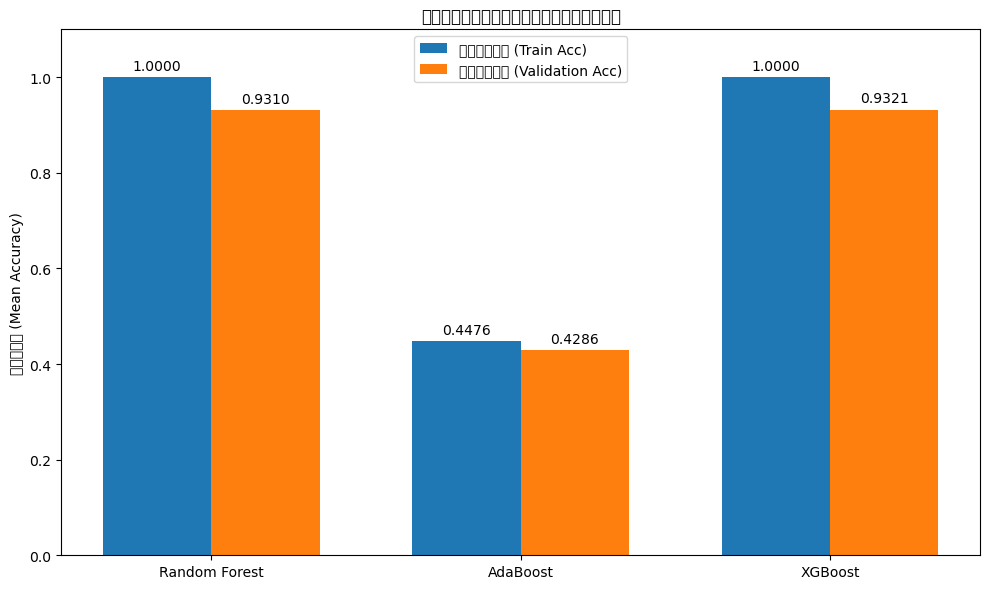

In [18]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate # <--- 导入 cross_validate
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

def run_model_comparison_with_overfitting_analysis(data_path: str):
    """
    加载数据，使用交叉验证对模型进行比较，并分析过拟合情况。
    """
    # --- 步骤 1: 加载预处理好的数据 ---
    try:
        with open(data_path, 'rb') as f:
            data_bundle = pickle.load(f)
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        print(f"✅ 成功加载 '{data_path}'。")
    except FileNotFoundError:
        print(f"❌ 错误：数据文件 '{data_path}' 未找到。")
        return

    # --- 步骤 2: 标签编码 ---
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train_text)
    print(f"✅ 标签编码完成。")

    # --- 步骤 3: 定义模型和交叉验证策略 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring_metrics = ['accuracy', 'f1_weighted'] # 我们关注这两个核心指标

    # --- 步骤 4: 执行交叉验证实验 ---
    print("\n🔄 开始进行交叉验证...")
    results = []
    for model_name, model in models.items():
        print(f"   - 正在评估: {model_name}...")
        
        # 使用 cross_validate 并设置 return_train_score=True
        cv_results = cross_validate(model, X_train, y_train_encoded, cv=kfold, 
                                    scoring=scoring_metrics, n_jobs=-1,
                                    return_train_score=True) # <--- 关键参数
        
        # 记录结果
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Test_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        model_result['Train_F1_Weighted_Mean'] = cv_results['train_f1_weighted'].mean()
        model_result['Test_F1_Weighted_Mean'] = cv_results['test_f1_weighted'].mean()
        results.append(model_result)

    # --- 步骤 5: 展示比选结果表格 ---
    results_df = pd.DataFrame(results).set_index('Model')
    print("\n\n🎉 --- 交叉验证完成 --- 🎉")
    print("模型性能比选结果 (含训练集与验证集):")
    print(results_df.round(4).to_string())
    
    # --- 步骤 6: 绘制簇状图进行可视化比较 ---
    print("\n🔄 正在绘制性能对比图...")
    
    # 准备绘图数据
    train_acc = results_df['Train_Accuracy_Mean']
    test_acc = results_df['Test_Accuracy_Mean']
    model_names = results_df.index
    
    x = np.arange(len(model_names))  # X轴位置
    width = 0.35  # 条形宽度

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='训练集准确率 (Train Acc)')
    rects2 = ax.bar(x + width/2, test_acc, width, label='验证集准确率 (Validation Acc)')

    # 添加文本标签、标题和图例
    ax.set_ylabel('平均准确率 (Mean Accuracy)')
    ax.set_title('各模型在训练集与验证集上的平均准确率对比')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1) # 设置Y轴范围

    fig.tight_layout()
    
    # 保存图像
    plt.savefig('../results/02_迁移诊断/model_comparison_accuracy.png')
    print("✅ 性能对比图已保存为 'model_comparison_accuracy.png'")
    plt.show()

# --- 如何使用 ---
if __name__ == "__main__":
    PROCESSED_DATA_FILE = '../data/processed/processed_data.pkl'
    run_model_comparison_with_overfitting_analysis(data_path=PROCESSED_DATA_FILE)

# V3

✅ Successfully loaded 'processed_data.pkl - 1'.
--- Stage 1: Model Comparison via Cross-Validation ---

🔄 Starting cross-validation...
   - Evaluating: Random Forest...
   - Evaluating: AdaBoost...
   - Evaluating: XGBoost...

🎉 --- Cross-Validation Complete --- 🎉
Model Performance Comparison:
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.9863
AdaBoost                    0.1429                    0.1429
XGBoost                     1.0000                    0.9780

🔄 Generating model comparison chart...
✅ Comparison chart saved to 'model_comparison_accuracy.png'


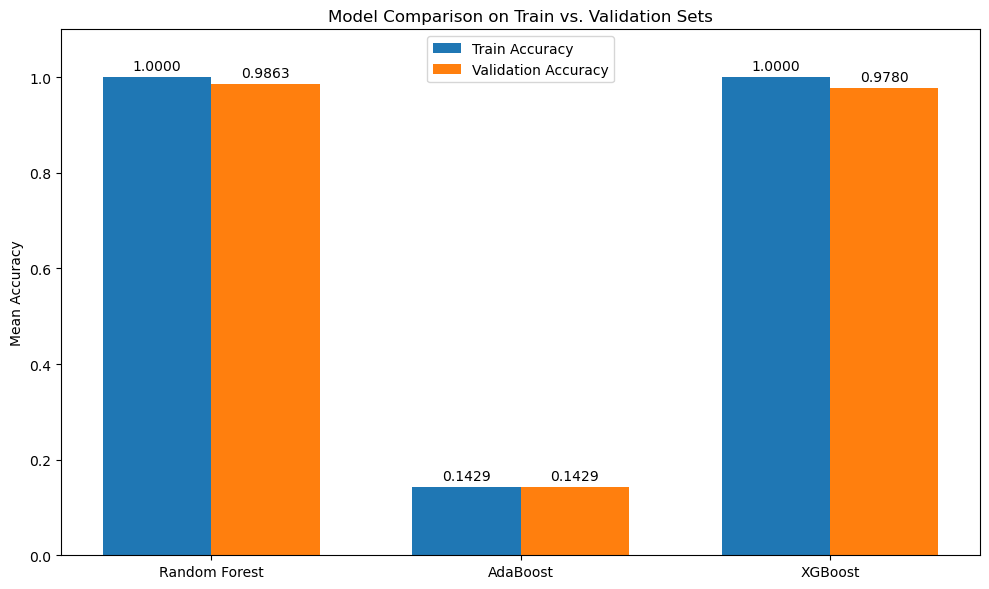


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 2: Final Training and Evaluation of the Best Model (Random Forest) ---

🔄 Training the final Random Forest model on all training data...
✅ Final model training complete.

🔄 Evaluating on the independent test set...

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9857

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       1.00      1.00      1.00        20
     DE_B_21       0.95      1.00      0.98        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       1.00      1.00      1.00        20
    DE_IR_14       1.00      0.95      0.97        20
    DE_IR_21       1.00      1.00      1.00        20
    DE_IR_28       1.00      1.00      1.00        20
     DE_IR_7       1.00      1.00      1.00        20
    DE_OR_14       1.00      1.00      1.00        20
    DE_OR_21       0.87      1.00      0.93        20
     DE_OR_7  

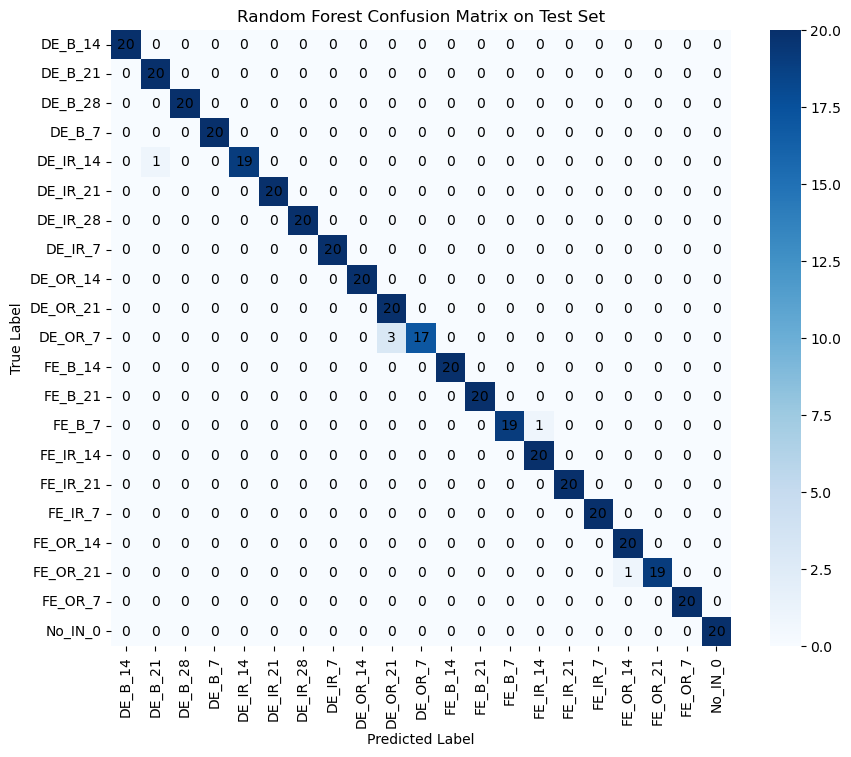

In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---

def plot_comparison_chart(results_df):
    """绘制模型比选的簇状条形图 (标题为英文)"""
    print("\n🔄 Generating model comparison chart...")
    
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    
    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')

    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Model Comparison on Train vs. Validation Sets')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1)

    fig.tight_layout()
    plt.savefig('../results/02_迁移诊断/model_comparison_accuracy.png')
    print("✅ Comparison chart saved to 'model_comparison_accuracy.png'")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """计算并绘制标准化的混淆矩阵图 (采用手动标注数字)"""
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # --- 关键修正 ---
    # 1. 我们先画一个没有自动标注的热力图 (annot=False)
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    
    # 2. 然后，我们用一个循环手动在每个格子上写上数字
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center", color="black", size=10)

    # 使用英文标签和标题
    ax.set_title(f'{model_name} Confusion Matrix on Test Set')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    print(f"✅ Confusion matrix saved to '{model_name.replace(' ', '_').lower()}_confusion_matrix.png'")
    plt.show()


# --- 主要实验函数 ---

def compare_models_via_cv(X_train, y_train, models, kfold):
    """通过交叉验证对多个模型进行性能比选"""
    print("--- Stage 1: Model Comparison via Cross-Validation ---")
    print("\n🔄 Starting cross-validation...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, 
                                    scoring=['accuracy'], n_jobs=-1,
                                    return_train_score=True)
        
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)

    results_df = pd.DataFrame(results).set_index('Model')
    print("\n🎉 --- Cross-Validation Complete --- 🎉")
    print("Model Performance Comparison:")
    print(results_df.round(4).to_string())
    
    plot_comparison_chart(results_df)
    
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name: str, X_train, y_train, X_test, y_test, le):
    """在全部训练集上训练指定模型，在测试集上评估"""
    print(f"\n--- Stage 2: Final Training and Evaluation of the Best Model ({model_name}) ---")
    
    print(f"\n🔄 Training the final {model_name} model on all training data...")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")

    print("\n🔄 Evaluating on the independent test set...")
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- Final Model Performance on Test Set ---")
    print(f"✅ Accuracy: {accuracy:.4f}")
    
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test_text, y_pred_text))

    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)


# --- 主执行函数 ---
if __name__ == "__main__":
    
    try:
        with open('../data/processed/processed_data.pkl - 1', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        X_test = data_bundle['X_test']
        y_test_text = data_bundle['y_test']
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl - 1'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded = le.transform(y_train_text)
    y_test_encoded = le.transform(y_test_text)
    
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    best_model_name = compare_models_via_cv(X_train, y_train_encoded, models, kfold)

    train_and_evaluate_final_model(
        model=models[best_model_name],
        model_name=best_model_name,
        X_train=X_train,
        y_train=y_train_encoded,
        X_test=X_test,
        y_test=y_test_encoded,
        le=le
    )


# V4

✅ Successfully loaded 'processed_data.pkl - 1'.

--- Model Input Details ---
✅ The model will be trained on the following 27 features:
   - rpm, Mean, RMS, Var, Skew
   - Kurt, CF, MF, P2P, FreqMean
   - FreqSTD, FreqSkew, FreqKurt, IR_Sideband_Energy_DE, IR_Sideband_Ratio_DE
   - B_Sideband_Energy_DE, B_Sideband_Ratio_DE, IR_Sideband_Energy_FE, IR_Sideband_Ratio_FE, B_Sideband_Energy_FE
   - B_Sideband_Ratio_FE, Env_Peak_BPFO_DE, Env_Peak_BPFI_DE, Env_Peak_BSF_DE, Env_Peak_BPFO_FE
   - Env_Peak_BPFI_FE, Env_Peak_BSF_FE

✅ The model will predict the following 21 labels:
   - ['DE_B_14', 'DE_B_21', 'DE_B_28', 'DE_B_7', 'DE_IR_14', 'DE_IR_21', 'DE_IR_28', 'DE_IR_7', 'DE_OR_14', 'DE_OR_21', 'DE_OR_7', 'FE_B_14', 'FE_B_21', 'FE_B_7', 'FE_IR_14', 'FE_IR_21', 'FE_IR_7', 'FE_OR_14', 'FE_OR_21', 'FE_OR_7', 'No_IN_0']

Label to Integer Mapping:
   - {'DE_B_14': 0, 'DE_B_21': 1, 'DE_B_28': 2, 'DE_B_7': 3, 'DE_IR_14': 4, 'DE_IR_21': 5, 'DE_IR_28': 6, 'DE_IR_7': 7, 'DE_OR_14': 8, 'DE_OR_21': 9, 'D

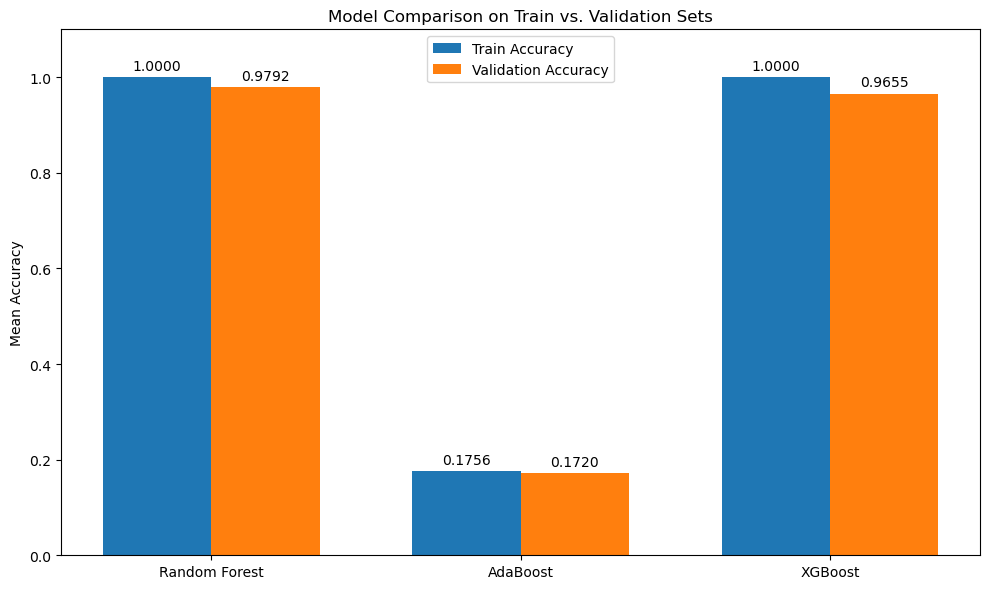


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 2: Final Training and Evaluation of the Best Model (Random Forest) ---

🔄 Training the final Random Forest model on all training data...
✅ Final model training complete.

🔄 Evaluating on the independent test set...

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9714

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.95      1.00      0.98        20
     DE_B_21       0.83      1.00      0.91        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       1.00      1.00      1.00        20
    DE_IR_14       1.00      0.95      0.97        20
    DE_IR_21       1.00      1.00      1.00        20
    DE_IR_28       1.00      1.00      1.00        20
     DE_IR_7       0.95      1.00      0.98        20
    DE_OR_14       0.90      0.95      0.93        20
    DE_OR_21       0.95      0.95      0.95        20
     DE_OR_7  

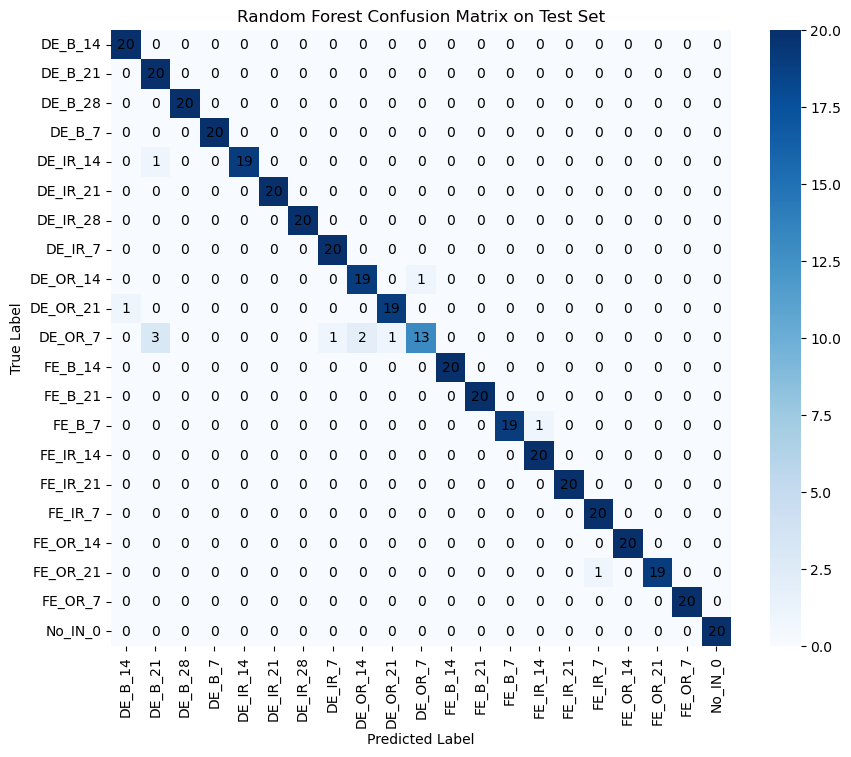


✅ Trained model has been saved to: 'random_forest_final_model.pkl'


In [13]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---

def plot_comparison_chart(results_df):
    """绘制模型比选的簇状条形图 (标题为英文)"""
    print("\n🔄 Generating model comparison chart...")
    
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    
    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')

    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Model Comparison on Train vs. Validation Sets')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1)

    fig.tight_layout()
    plt.savefig('../results/02_迁移诊断/model_comparison_accuracy.png')
    print("✅ Comparison chart saved to 'model_comparison_accuracy.png'")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """计算并绘制标准化的混淆矩阵图 (采用手动标注数字)"""
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center", color="black", size=10)

    ax.set_title(f'{model_name} Confusion Matrix on Test Set')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    print(f"✅ Confusion matrix saved to '{model_name.replace(' ', '_').lower()}_confusion_matrix.png'")
    plt.show()


# --- 主要实验函数 ---

def compare_models_via_cv(X_train, y_train, models, kfold):
    """通过交叉验证对多个模型进行性能比选"""
    print("\n--- Stage 1: Model Comparison via Cross-Validation ---")
    print("\n🔄 Starting cross-validation...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, 
                                    scoring=['accuracy'], n_jobs=-1,
                                    return_train_score=True)
        
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)

    results_df = pd.DataFrame(results).set_index('Model')
    print("\n🎉 --- Cross-Validation Complete --- 🎉")
    print("Model Performance Comparison:")
    print(results_df.round(4).to_string())
    
    plot_comparison_chart(results_df)
    
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name: str, X_train, y_train, X_test, y_test, le):
    """在全部训练集上训练指定模型，在测试集上评估"""
    print(f"\n--- Stage 2: Final Training and Evaluation of the Best Model ({model_name}) ---")
    
    print(f"\n🔄 Training the final {model_name} model on all training data...")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")

    print("\n🔄 Evaluating on the independent test set...")
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- Final Model Performance on Test Set ---")
    print(f"✅ Accuracy: {accuracy:.4f}")
    
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test_text, y_pred_text))

    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    
    # 保存模型
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    try:
        # **注意**：您之前的文件名是 '../data/processed/processed_data.pkl - 1'，请确保这里的文件名正确
        with open('../data/processed/processed_data.pkl - 1', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        X_test = data_bundle['X_test']
        y_test_text = data_bundle['y_test']
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl - 1'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl - 1' not found.")
        exit()

    # --- 标签编码 ---
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded = le.transform(y_train_text)
    y_test_encoded = le.transform(y_test_text)
    
    
    # --- 【新增功能】: 打印特征和标签列表 ---
    print("\n" + "="*50)
    print("--- Model Input Details ---")
    
    # 打印特征列表
    feature_list = X_train.columns.tolist()
    print(f"✅ The model will be trained on the following {len(feature_list)} features:")
    # 为了美观，每行打印5个特征
    features_per_line = 5
    for i in range(0, len(feature_list), features_per_line):
        print("   - " + ", ".join(feature_list[i:i+features_per_line]))
        
    # 打印标签列表
    label_list = le.classes_.tolist()
    print(f"\n✅ The model will predict the following {len(label_list)} labels:")
    print(f"   - {label_list}")
    print("\nLabel to Integer Mapping:")
    print("   - " + str(dict(zip(le.classes_, le.transform(le.classes_)))))
    print("="*50)
    # --- 新增功能结束 ---


    # --- 定义模型 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    # --- 执行实验 ---
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_model_name = compare_models_via_cv(X_train, y_train_encoded, models, kfold)
    train_and_evaluate_final_model(
        model=models[best_model_name],
        model_name=best_model_name,
        X_train=X_train,
        y_train=y_train_encoded,
        X_test=X_test,
        y_test=y_test_encoded,
        le=le
    )

In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---

def plot_comparison_chart(results_df):
    """绘制模型比选的簇状条形图 (标题为英文)"""
    print("\n🔄 Generating model comparison chart...")
    
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    
    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')

    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Model Comparison on Train vs. Validation Sets')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1)

    fig.tight_layout()
    plt.savefig('../results/02_迁移诊断/model_comparison_accuracy.png')
    print("✅ Comparison chart saved to 'model_comparison_accuracy.png'")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """计算并绘制标准化的混淆矩阵图 (采用手动标注数字)"""
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center", color="black", size=10)

    ax.set_title(f'{model_name} Confusion Matrix on Test Set')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    print(f"✅ Confusion matrix saved to '{model_name.replace(' ', '_').lower()}_confusion_matrix.png'")
    plt.show()

# --- 【新增】独立的特征重要性绘图函数 ---
def plot_feature_importance(model, feature_names, model_name):
    """
    为训练好的模型绘制特征重要性条形图。
    """
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    
    # 检查模型是否具有 feature_importances_ 属性
    if not hasattr(model, 'feature_importances_'):
        print(f"   - Model {model_name} does not have 'feature_importances_' attribute. Skipping plot.")
        return

    # 创建一个包含特征名和重要性得分的DataFrame
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # 只展示最重要的前20个特征
    top_features = feature_importance_df.head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=top_features)
    
    plt.title(f'Top 20 Feature Importances for {model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    
    plt.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    print(f"✅ Feature importance chart saved to '{model_name.replace(' ', '_').lower()}_feature_importance.png'")
    plt.show()


# --- 主要实验函数 ---

def compare_models_via_cv(X_train, y_train, models, kfold):
    """通过交叉验证对多个模型进行性能比选"""
    print("\n--- Stage 1: Model Comparison via Cross-Validation ---")
    print("\n🔄 Starting cross-validation...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, 
                                    scoring=['accuracy'], n_jobs=-1,
                                    return_train_score=True)
        
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)

    results_df = pd.DataFrame(results).set_index('Model')
    print("\n🎉 --- Cross-Validation Complete --- 🎉")
    print("Model Performance Comparison:")
    print(results_df.round(4).to_string())
    
    plot_comparison_chart(results_df)
    
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name: str, X_train, y_train, X_test, y_test, le):
    """在全部训练集上训练指定模型，在测试集上评估，并展示特征重要性"""
    print(f"\n--- Stage 2: Final Training and Evaluation of the Best Model ({model_name}) ---")
    
    print(f"\n🔄 Training the final {model_name} model on all training data...")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")

    print("\n🔄 Evaluating on the independent test set...")
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- Final Model Performance on Test Set ---")
    print(f"✅ Accuracy: {accuracy:.4f}")
    
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test_text, y_pred_text))

    # 绘制混淆矩阵
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    
    # **【新增】** 调用特征重要性绘图函数
    # 我们需要传递训练好的模型和特征的名字列表 (X_train.columns)
    plot_feature_importance(model, X_train.columns, model_name)
    
    # 保存模型
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    try:
        # **注意**：请确保这里的文件名正确
        with open('../data/processed/processed_data.pkl - 1', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        X_test = data_bundle['X_test']
        y_test_text = data_bundle['y_test']
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl - 1'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl - 1' not found.")
        exit()

    # --- 标签编码 ---
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded = le.transform(y_train_text)
    y_test_encoded = le.transform(y_test_text)
    
    
    # --- 打印特征和标签列表 ---
    print("\n" + "="*50)
    print("--- Model Input Details ---")
    
    feature_list = X_train.columns.tolist()
    print(f"✅ The model will be trained on the following {len(feature_list)} features:")
    features_per_line = 5
    for i in range(0, len(feature_list), features_per_line):
        print("   - " + ", ".join(feature_list[i:i+features_per_line]))
        
    label_list = le.classes_.tolist()
    print(f"\n✅ The model will predict the following {len(label_list)} labels:")
    print(f"   - {label_list}")
    print("\nLabel to Integer Mapping:")
    print("   - " + str(dict(zip(le.classes_, le.transform(le.classes_)))))
    print("="*50)

    # --- 定义模型 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    # --- 执行实验 ---
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_model_name = compare_models_via_cv(X_train, y_train_encoded, models, kfold)
    train_and_evaluate_final_model(
        model=models[best_model_name],
        model_name=best_model_name,
        X_train=X_train,
        y_train=y_train_encoded,
        X_test=X_test,
        y_test=y_test_encoded,
        le=le
    )

✅ Successfully loaded 'processed_data.pkl - 1'.

--- Model Input Details ---
✅ The model will be trained on the following 27 features:
   - rpm, Mean, RMS, Var, Skew
   - Kurt, CF, MF, P2P, FreqMean
   - FreqSTD, FreqSkew, FreqKurt, IR_Sideband_Energy_DE, IR_Sideband_Ratio_DE
   - B_Sideband_Energy_DE, B_Sideband_Ratio_DE, IR_Sideband_Energy_FE, IR_Sideband_Ratio_FE, B_Sideband_Energy_FE
   - B_Sideband_Ratio_FE, Env_Peak_BPFO_DE, Env_Peak_BPFI_DE, Env_Peak_BSF_DE, Env_Peak_BPFO_FE
   - Env_Peak_BPFI_FE, Env_Peak_BSF_FE

✅ The model will predict the following 21 labels:
   - ['DE_B_14', 'DE_B_21', 'DE_B_28', 'DE_B_7', 'DE_IR_14', 'DE_IR_21', 'DE_IR_28', 'DE_IR_7', 'DE_OR_14', 'DE_OR_21', 'DE_OR_7', 'FE_B_14', 'FE_B_21', 'FE_B_7', 'FE_IR_14', 'FE_IR_21', 'FE_IR_7', 'FE_OR_14', 'FE_OR_21', 'FE_OR_7', 'No_IN_0']

Label to Integer Mapping:
   - {'DE_B_14': 0, 'DE_B_21': 1, 'DE_B_28': 2, 'DE_B_7': 3, 'DE_IR_14': 4, 'DE_IR_21': 5, 'DE_IR_28': 6, 'DE_IR_7': 7, 'DE_OR_14': 8, 'DE_OR_21': 9, 'D

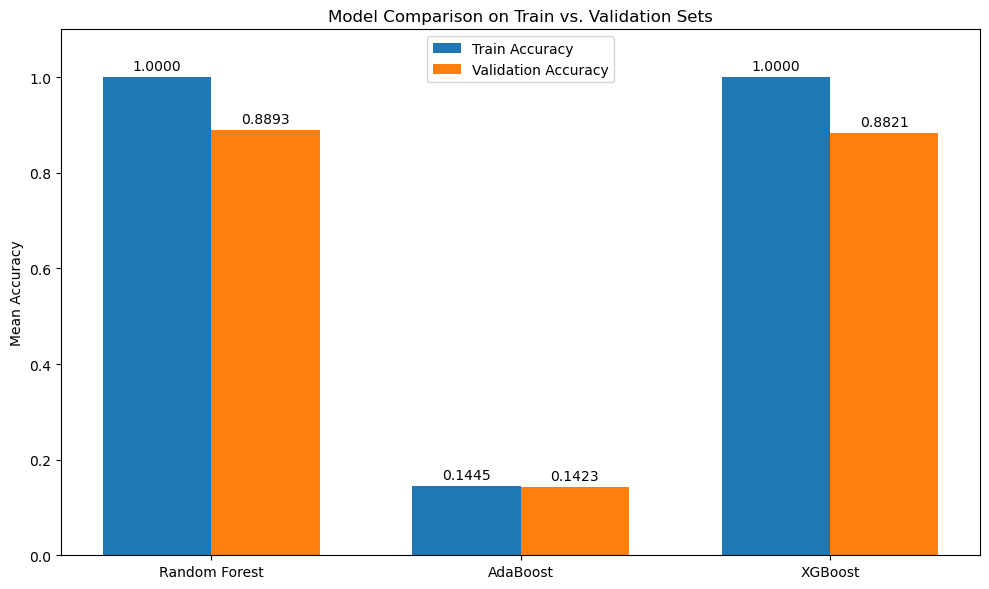


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 2: Final Training and Evaluation of the Best Model (Random Forest) ---

🔄 Training the final Random Forest model on all training data...
✅ Final model training complete.

🔄 Evaluating on the independent test set...

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9048

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.78      0.90      0.84        20
     DE_B_21       0.89      0.80      0.84        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.77      1.00      0.87        20
    DE_IR_14       0.90      0.90      0.90        20
    DE_IR_21       1.00      0.80      0.89        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.83      0.95      0.88        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.83      0.75      0.79        20
     DE_OR_7  

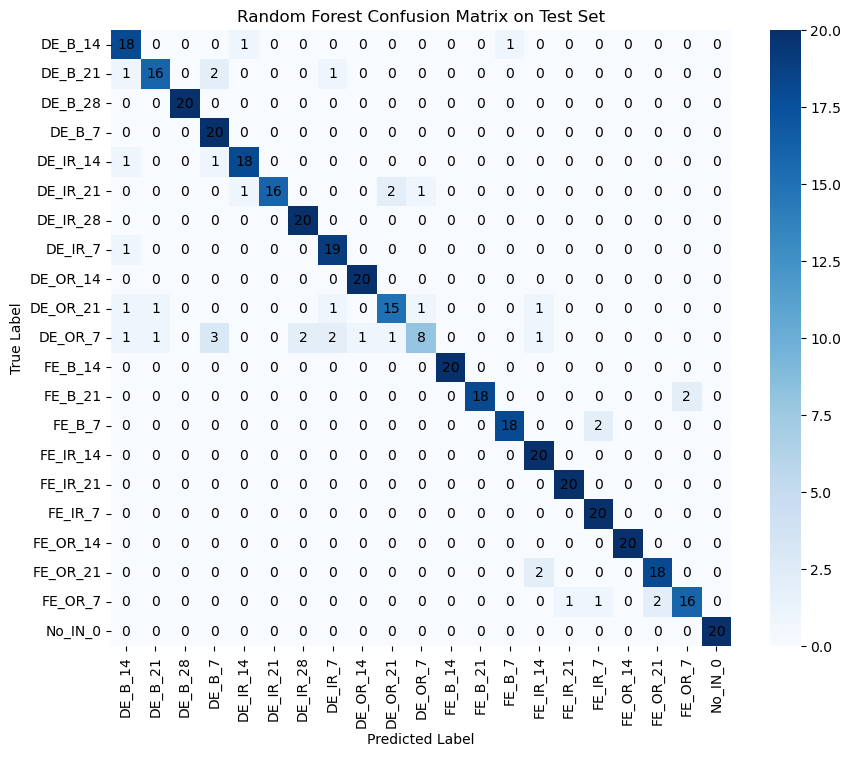


🔄 Generating feature importance chart for Random Forest...
✅ Feature importance chart saved to 'random_forest_feature_importance.png'


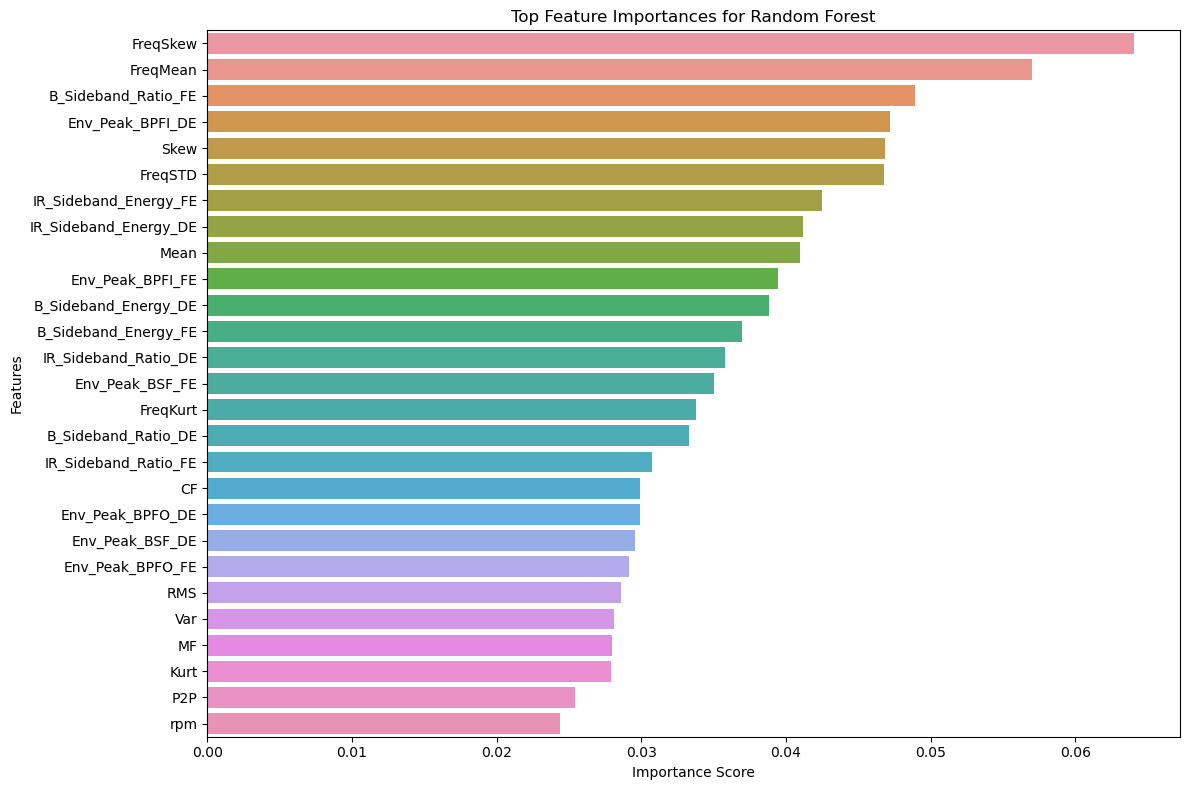


✅ Trained model has been saved to: 'random_forest_final_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---

def plot_comparison_chart(results_df):
    """绘制模型比选的簇状条形图 (标题为英文)"""
    print("\n🔄 Generating model comparison chart...")
    
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    
    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')

    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Model Comparison on Train vs. Validation Sets')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f')
    ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1)

    fig.tight_layout()
    plt.savefig('../results/02_迁移诊断/model_comparison_accuracy.png')
    print("✅ Comparison chart saved to 'model_comparison_accuracy.png'")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """计算并绘制标准化的混淆矩阵图 (采用手动标注数字)"""
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center", color="black", size=10)

    ax.set_title(f'{model_name} Confusion Matrix on Test Set')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    print(f"✅ Confusion matrix saved to '{model_name.replace(' ', '_').lower()}_confusion_matrix.png'")
    plt.show()

# --- 【新增】独立的特征重要性绘图函数 ---
def plot_feature_importance(model, feature_names, model_name):
    """
    为训练好的模型绘制特征重要性条形图。
    """
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    
    # 检查模型是否具有 feature_importances_ 属性
    if not hasattr(model, 'feature_importances_'):
        print(f"   - Model {model_name} does not have 'feature_importances_' attribute. Skipping plot.")
        return

    # 创建一个包含特征名和重要性得分的DataFrame
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # 只展示最重要的前20个特征
    top_features = feature_importance_df

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=top_features)
    
    plt.title(f'Top Feature Importances for {model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    
    plt.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    print(f"✅ Feature importance chart saved to '{model_name.replace(' ', '_').lower()}_feature_importance.png'")
    plt.show()


# --- 主要实验函数 ---

def compare_models_via_cv(X_train, y_train, models, kfold):
    """通过交叉验证对多个模型进行性能比选"""
    print("\n--- Stage 1: Model Comparison via Cross-Validation ---")
    print("\n🔄 Starting cross-validation...")
    
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, 
                                    scoring=['accuracy'], n_jobs=-1,
                                    return_train_score=True)
        
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)

    results_df = pd.DataFrame(results).set_index('Model')
    print("\n🎉 --- Cross-Validation Complete --- 🎉")
    print("Model Performance Comparison:")
    print(results_df.round(4).to_string())
    
    plot_comparison_chart(results_df)
    
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name: str, X_train, y_train, X_test, y_test, le):
    """在全部训练集上训练指定模型，在测试集上评估，并展示特征重要性"""
    print(f"\n--- Stage 2: Final Training and Evaluation of the Best Model ({model_name}) ---")
    
    print(f"\n🔄 Training the final {model_name} model on all training data...")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")

    print("\n🔄 Evaluating on the independent test set...")
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- Final Model Performance on Test Set ---")
    print(f"✅ Accuracy: {accuracy:.4f}")
    
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test_text, y_pred_text))

    # 绘制混淆矩阵
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    
    # **【新增】** 调用特征重要性绘图函数
    # 我们需要传递训练好的模型和特征的名字列表 (X_train.columns)
    plot_feature_importance(model, X_train.columns, model_name)
    
    # 保存模型
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    try:
        # **注意**：请确保这里的文件名正确
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        X_test = data_bundle['X_test']
        y_test_text = data_bundle['y_test']
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl - 1'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl - 1' not found.")
        exit()

    # --- 标签编码 ---
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded = le.transform(y_train_text)
    y_test_encoded = le.transform(y_test_text)
    
    
    # --- 打印特征和标签列表 ---
    print("\n" + "="*50)
    print("--- Model Input Details ---")
    
    feature_list = X_train.columns.tolist()
    print(f"✅ The model will be trained on the following {len(feature_list)} features:")
    features_per_line = 5
    for i in range(0, len(feature_list), features_per_line):
        print("   - " + ", ".join(feature_list[i:i+features_per_line]))
        
    label_list = le.classes_.tolist()
    print(f"\n✅ The model will predict the following {len(label_list)} labels:")
    print(f"   - {label_list}")
    print("\nLabel to Integer Mapping:")
    print("   - " + str(dict(zip(le.classes_, le.transform(le.classes_)))))
    print("="*50)

    # --- 定义模型 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }

    # --- 执行实验 ---
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_model_name = compare_models_via_cv(X_train, y_train_encoded, models, kfold)
    train_and_evaluate_final_model(
        model=models[best_model_name],
        model_name=best_model_name,
        X_train=X_train,
        y_train=y_train_encoded,
        X_test=X_test,
        y_test=y_test_encoded,
        le=le
    )

# RFECV

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier as the estimator...
✅ RFECV complete.
   - Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison via Cross-Validation (After Feature Selection) ---

🔄 Starting cross-validation...
   - Evaluating: Random Forest...
   - Evaluating: AdaBoost...
   - Evaluating: XGBoost...

🎉 --- Cross-Validation Complete --- 🎉
Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Me

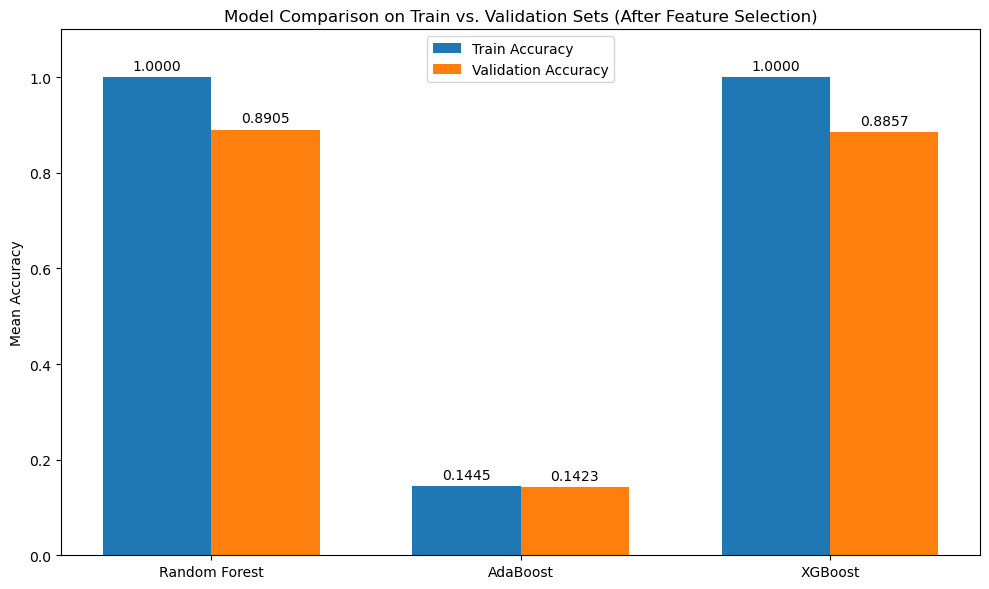


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation of the Best Model (Random Forest) ---

🔄 Training the final Random Forest model on all training data...
✅ Final model training complete.

🔄 Evaluating on the independent test set...

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7  

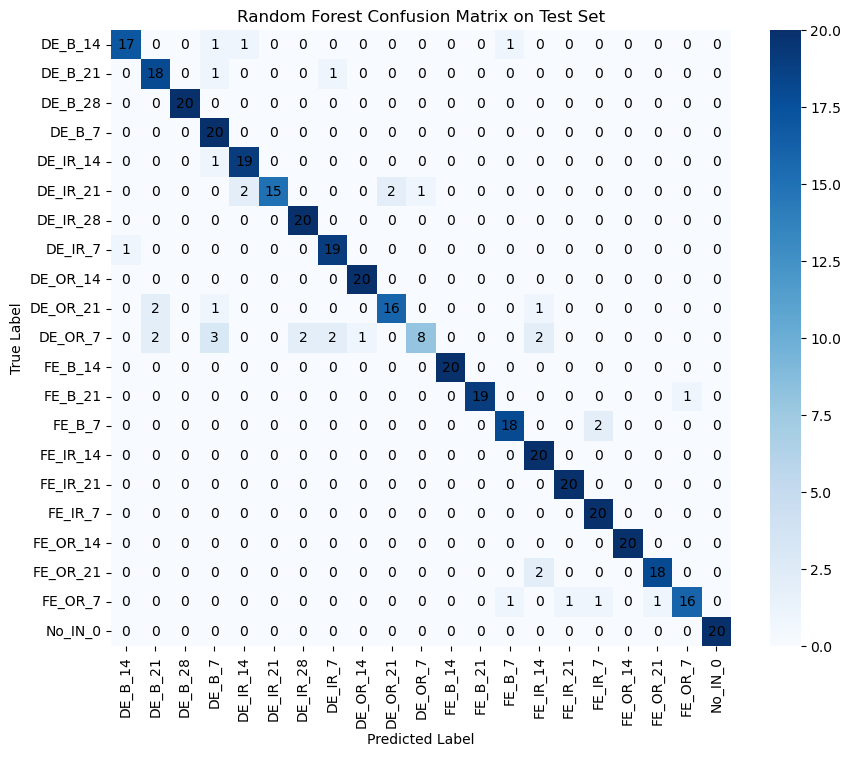


🔄 Generating feature importance chart for Random Forest...


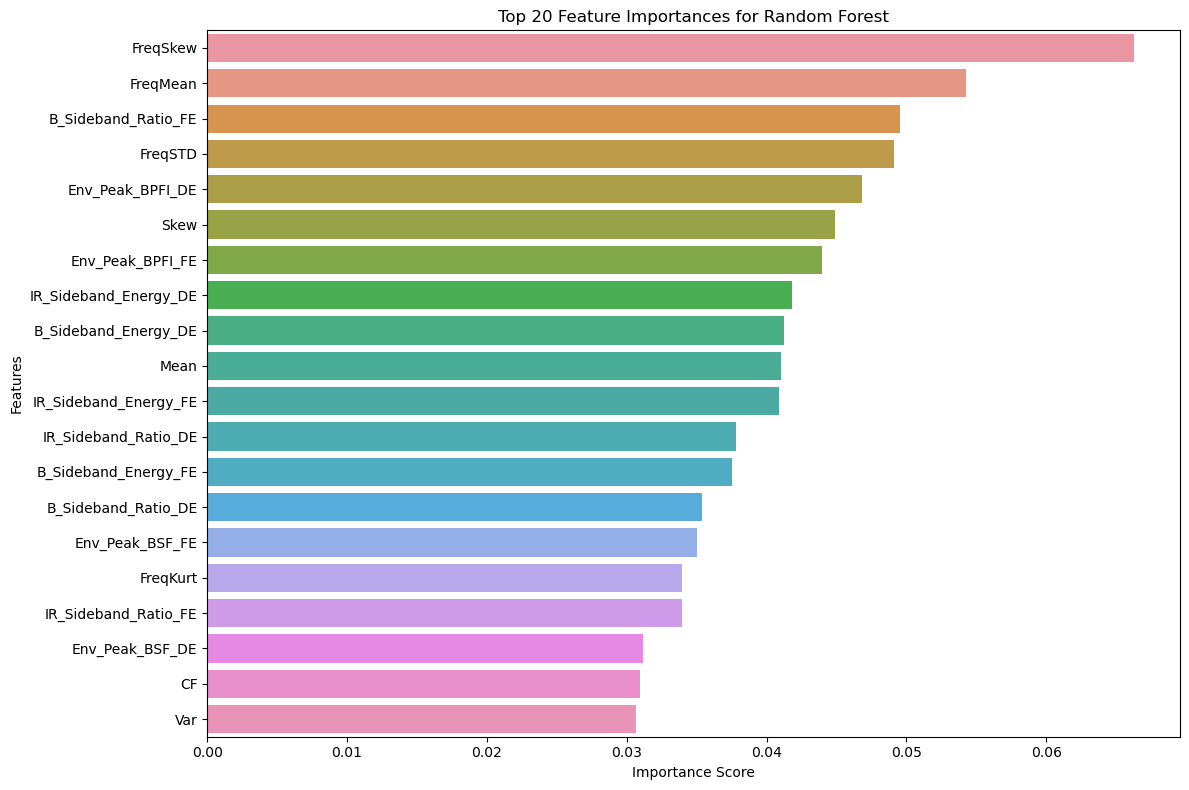


✅ Trained model has been saved to: 'random_forest_final_model.pkl'


In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 新增导入 RFECV
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 (保持不变) ---
def plot_comparison_chart(results_df, title_suffix=""):
    """绘制模型比选的簇状条形图"""
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """计算并绘制标准化的混淆矩阵图"""
    print("\n🔄 Generating confusion matrix chart...")
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()


def plot_feature_importance(model, feature_names, model_name):
    """为训练好的模型绘制特征重要性条形图"""
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    if not hasattr(model, 'feature_importances_'):
        print(f"   - Model {model_name} does not have 'feature_importances_' attribute. Skipping plot.")
        return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 20 Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 【新增】独立的特征选择函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    """
    使用RFECV进行特征选择，并返回最优的特征子集。
    """
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__} as the estimator...")
    
    # 初始化RFECV
    # 我们使用f1_weighted作为评估标准，因为它对不平衡数据更稳健
    rfecv = RFECV(
        estimator=model_for_selection,
        step=1,
        cv=kfold,
        scoring="f1_weighted",
        min_features_to_select=5, # 保证最少选出5个特征
        n_jobs=-1
    )
    
    # 执行特征选择
    rfecv.fit(X_train, y_train)
    
    # 打印结果
    print(f"✅ RFECV complete.")
    print(f"   - Optimal number of features found: {rfecv.n_features_}")
    
    # 获取被选中的特征名称
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    
    # 使用选出的特征来转换数据集
    X_train_selected = rfecv.transform(X_train)
    
    # 将Numpy数组转回有列名的DataFrame
    X_train_selected_df = pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features)
    
    return X_train_selected_df, selected_features

# --- 主要实验函数 (已更新) ---
def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    """通过交叉验证对多个模型进行性能比选"""
    print(f"\n--- Stage {2 if title_suffix else 1}: Model Comparison via Cross-Validation{title_suffix} ---")
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    print("\n🔄 Starting cross-validation...")
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print("\n🎉 --- Cross-Validation Complete --- 🎉")
    print(f"Model Performance Comparison{title_suffix}:")
    print(results_df.round(4).to_string())
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name


def train_and_evaluate_final_model(model, model_name: str, X_train, y_train, X_test, y_test, le):
    """在全部训练集上训练指定模型，在测试集上评估"""
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    print(f"\n--- Stage 3: Final Training and Evaluation of the Best Model ({model_name}) ---")
    print(f"\n🔄 Training the final {model_name} model on all training data...")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    print("\n🔄 Evaluating on the independent test set...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- Final Model Performance on Test Set ---")
    print(f"✅ Accuracy: {accuracy:.4f}")
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    print("\n📋 Classification Report:")
    print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # --- 加载数据 ---
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full = data_bundle['X_train']
        y_train_text = data_bundle['y_train']
        X_test_full = data_bundle['X_test']
        y_test_text = data_bundle['y_test']
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # --- 标签编码 ---
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded = le.transform(y_train_text)
    y_test_encoded = le.transform(y_test_text)
    
    # --- 定义模型 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # =========================================================================
    # **【新增阶段】: 使用RFECV进行特征选择**
    # =========================================================================
    
    # 我们选用一个强大的模型（如XGBoost）来帮助我们进行特征重要性判断
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    
    # 执行特征选择
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    
    # 别忘了用选出的特征来筛选测试集
    X_test_selected = X_test_full[selected_feature_names]

    # =========================================================================
    # **【更新阶段】: 在筛选后的特征上重新进行模型比选**
    # =========================================================================
    
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # =========================================================================
    # **【最终阶段】: 训练、评估并保存最优模型**
    # =========================================================================

    train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

## RFECV + 最终预测

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier as the estimator...
✅ RFECV complete. Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison via Cross-Validation (After Feature Selection) ---

Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8905
AdaBoost                    0.1445       

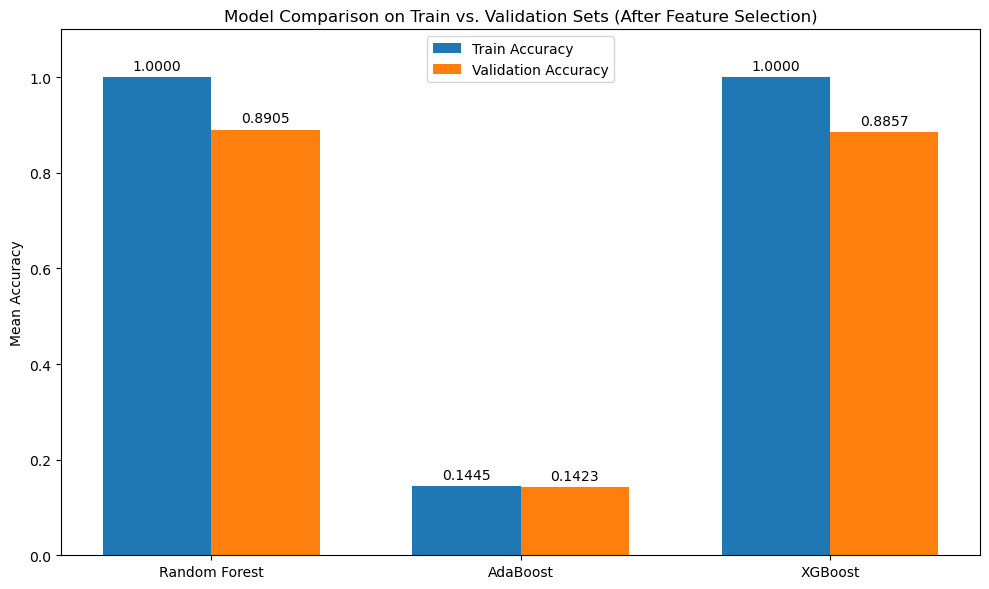


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation of the Best Model (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7       0.89      0.40      0.55        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21     

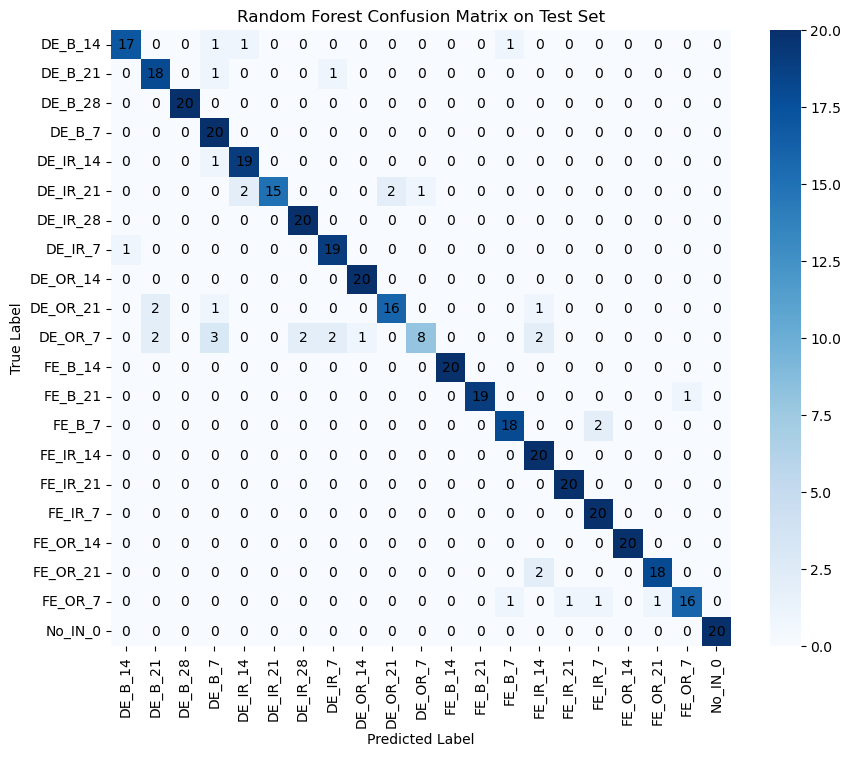


🔄 Generating feature importance chart for Random Forest...


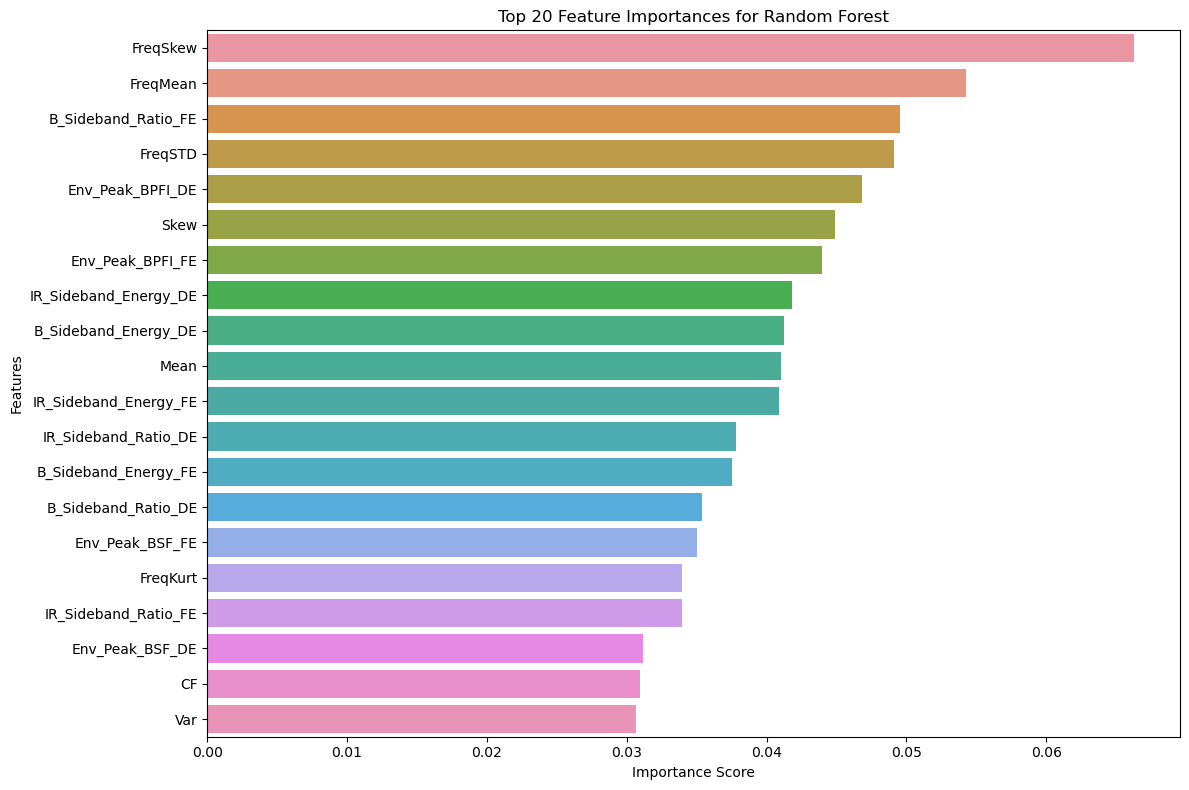


✅ Trained model has been saved to: 'random_forest_final_model.pkl'

--- Final Stage: Predicting on Target Domain Data ---
✅ Successfully loaded 'processed_data - target.pkl'.

🔄 Aligning target data with the 26 selected features...
✅ Target data aligned. Shape: (16, 26)

🔄 Predicting with the final Random Forest model...

🎉 --- Target Domain Prediction Complete --- 🎉
Final Predictions:
    Sample_Index Predicted_Label
0              0         DE_B_14
1              1        DE_OR_21
2              2         DE_B_28
3              3         FE_B_14
4              4         DE_B_28
5              5        FE_IR_14
6              6         DE_B_14
7              7         DE_B_28
8              8        DE_IR_21
9              9         DE_B_28
10            10         No_IN_0
11            11         No_IN_0
12            12         DE_B_14
13            13         DE_B_28
14            14         DE_B_14
15            15         FE_B_14

✅ Predictions have been saved to 'target_domain_

In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 (保持不变) ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 20 Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 特征选择与实验函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__} as the estimator...")
    rfecv = RFECV(estimator=model_for_selection, step=1, cv=kfold, scoring="f1_weighted", min_features_to_select=5, n_jobs=-1)
    rfecv.fit(X_train, y_train)
    print(f"✅ RFECV complete. Optimal number of features found: {rfecv.n_features_}")
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    X_train_selected = rfecv.transform(X_train)
    return pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features), selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage 2: Model Comparison via Cross-Validation{title_suffix} ---")
    # ... (函数体与之前相同, 此处省略)
    results = []
    for model_name, model in models.items():
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name, 'Train_Accuracy_Mean': cv_results['train_accuracy'].mean(), 'Validation_Accuracy_Mean': cv_results['test_accuracy'].mean()}
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:\n{results_df.round(4).to_string()}")
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation of the Best Model ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text, y_pred_text = le.inverse_transform(y_test), le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")
    # **【新增】** 返回训练好的最终模型
    return model


# --- 【新增】独立的对目标域进行预测的函数 ---
def predict_target_domain(model, model_name: str, target_data_path: str, selected_features: list, le: LabelEncoder):
    """
    加载处理好的目标域数据，并使用最终模型进行预测。
    """
    print("\n" + "="*50)
    print("--- Final Stage: Predicting on Target Domain Data ---")
    print("="*50)

    # --- 步骤 1: 加载预处理好的目标域数据 ---
    try:
        with open(target_data_path, 'rb') as f:
            target_data_bundle = pickle.load(f)
        X_target = target_data_bundle['X_target']
        print(f"✅ Successfully loaded '{target_data_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: Target data file '{target_data_path}' not found.")
        return

    # --- 步骤 2: 确保特征列完全一致 ---
    # 使用特征选择阶段选出的特征来筛选目标域数据
    print(f"\n🔄 Aligning target data with the {len(selected_features)} selected features...")
    X_target_selected = X_target[selected_features]
    print(f"✅ Target data aligned. Shape: {X_target_selected.shape}")

    # --- 步骤 3: 使用最终模型进行预测 ---
    print(f"\n🔄 Predicting with the final {model_name} model...")
    target_predictions_encoded = model.predict(X_target_selected)
    
    # --- 步骤 4: 将预测结果解码回文本标签 ---
    target_predictions_text = le.inverse_transform(target_predictions_encoded)
    
    # --- 步骤 5: 展示并保存预测结果 ---
    predictions_df = pd.DataFrame({
        'Sample_Index': X_target.index,
        'Predicted_Label': target_predictions_text
    })

    print("\n🎉 --- Target Domain Prediction Complete --- 🎉")
    print("Final Predictions:")
    print(predictions_df.to_string())
    
    output_filename = '../results/预测结果/target_domain_predictions.csv'
    predictions_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions have been saved to '{output_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # --- 加载数据 ---
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # --- 标签编码 ---
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    # --- 定义模型 ---
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # **阶段 1: 特征选择**
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    X_test_selected = X_test_full[selected_feature_names]

    # **阶段 2: 在筛选后的特征上重新比选模型**
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # **阶段 3: 训练、评估并保存最终模型**
    final_trained_model = train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

    # **【最终阶段】: 对目标域数据进行预测**
    predict_target_domain(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        target_data_path='../data/processed/processed_data - target.pkl', # <-- 指定处理好的目标域数据
        selected_features=selected_feature_names,
        le=le
    )

## 加入SHAP

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier...
✅ RFECV complete. Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison (After Feature Selection) ---

Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8905
AdaBoost                    0.1445                    0.1423
XGBoost           

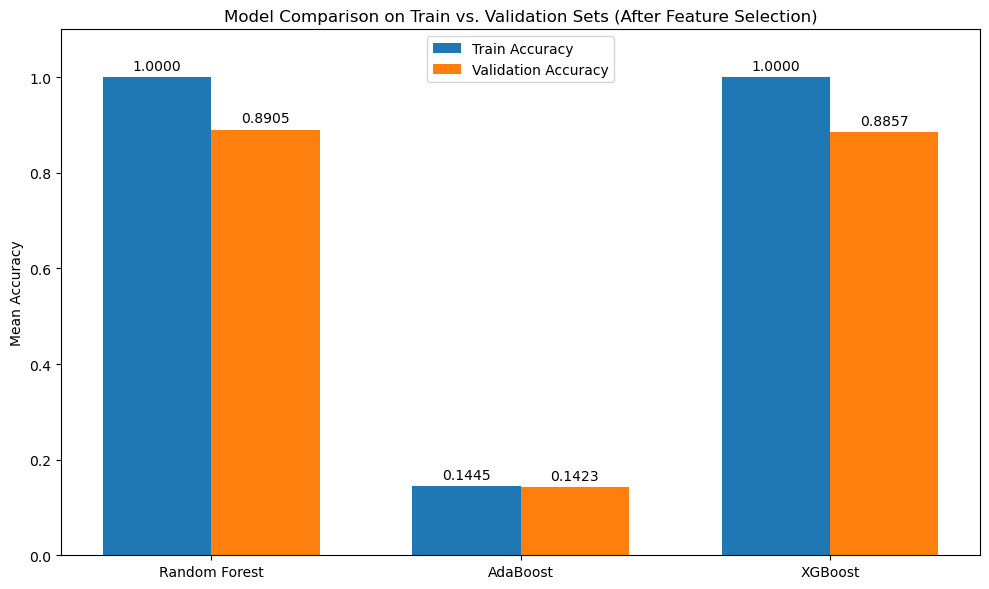


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7       0.89      0.40      0.55        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21       1.00      0.95  

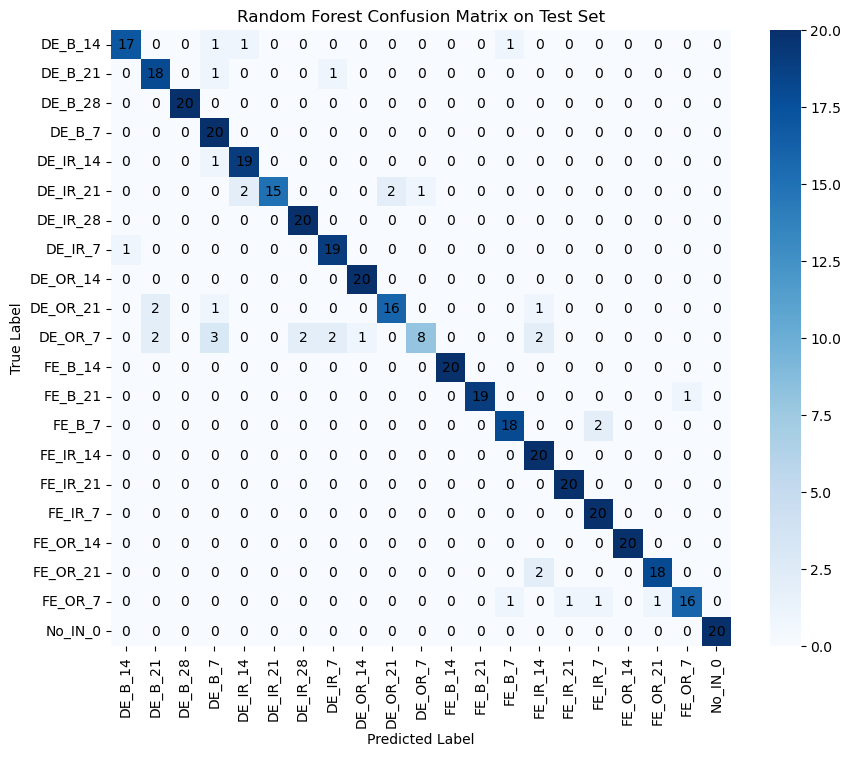


🔄 Generating feature importance chart for Random Forest...


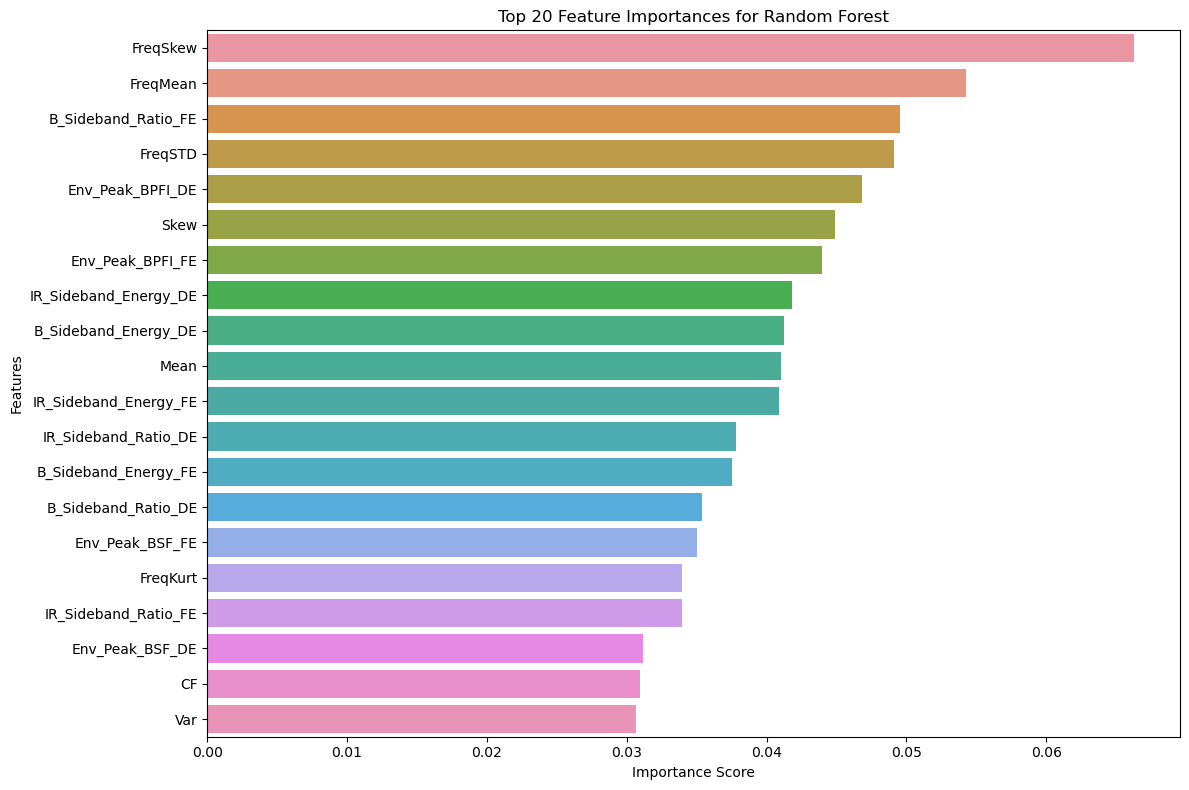


✅ Trained model has been saved to: 'random_forest_final_model.pkl'

--- Stage 4: Predicting on Target Domain Data ---
✅ Successfully loaded 'processed_data - target.pkl'.

🔄 Aligning target data with the 26 selected features...
✅ Target data aligned. Shape: (16, 26)

🔄 Predicting with the final Random Forest model...

🎉 --- Target Domain Prediction Complete --- 🎉
Final Predictions:
    Sample_Index Predicted_Label
0              0         DE_B_14
1              1        DE_OR_21
2              2         DE_B_28
3              3         FE_B_14
4              4         DE_B_28
5              5        FE_IR_14
6              6         DE_B_14
7              7         DE_B_28
8              8        DE_IR_21
9              9         DE_B_28
10            10         No_IN_0
11            11         No_IN_0
12            12         DE_B_14
13            13         DE_B_28
14            14         DE_B_14
15            15         FE_B_14

✅ Predictions have been saved to 'target_domain_pred

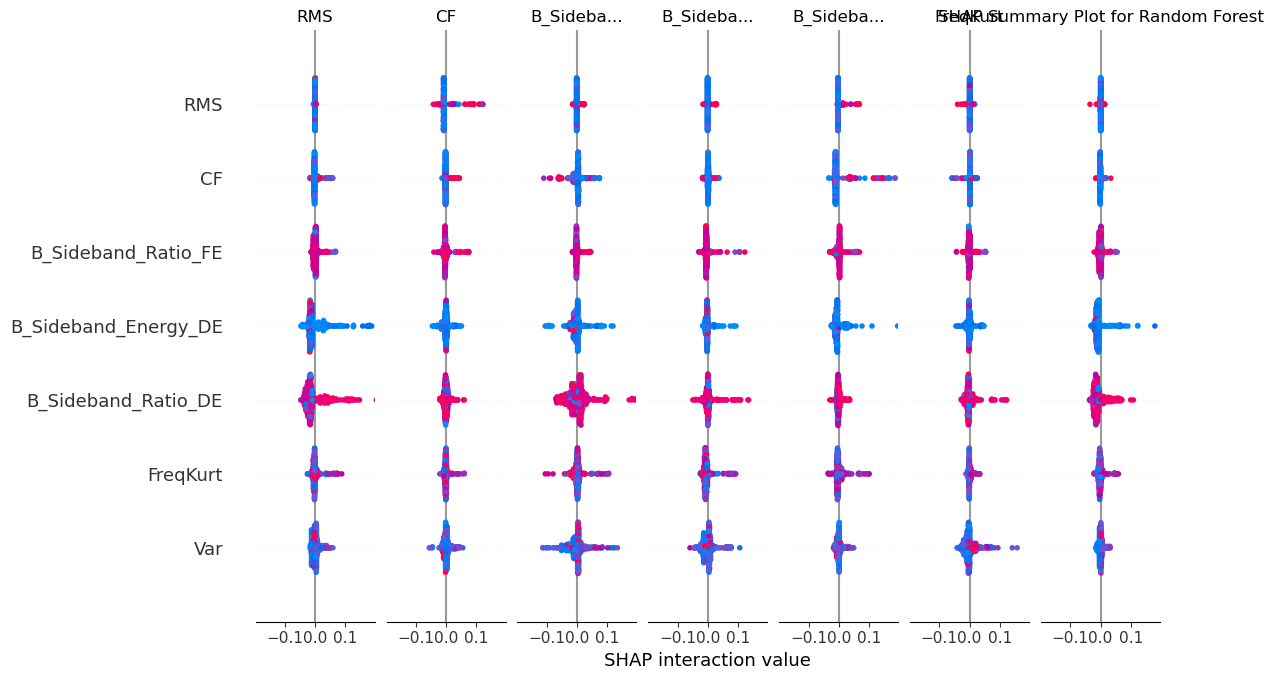

✅ SHAP summary plot saved.


In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
# 新增导入 shap
import shap
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 (保持不变) ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20) # 修正：标题与这里的数值应一致
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {len(top_features)} Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 主要实验函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__}...")
    rfecv = RFECV(estimator=model_for_selection, step=1, cv=kfold, scoring="f1_weighted", min_features_to_select=5, n_jobs=-1)
    rfecv.fit(X_train, y_train)
    print(f"✅ RFECV complete. Optimal number of features found: {rfecv.n_features_}")
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    X_train_selected = rfecv.transform(X_train)
    return pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features), selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage 2: Model Comparison{title_suffix} ---")
    results = []
    for model_name, model in models.items():
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name, 'Train_Accuracy_Mean': cv_results['train_accuracy'].mean(), 'Validation_Accuracy_Mean': cv_results['test_accuracy'].mean()}
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:\n{results_df.round(4).to_string()}")
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text, y_pred_text = le.inverse_transform(y_test), le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")
    return model

def predict_target_domain(model, model_name, target_data_path, selected_features, le):
    print("\n" + "="*50 + f"\n--- Stage 4: Predicting on Target Domain Data ---")
    try:
        with open(target_data_path, 'rb') as f:
            target_data_bundle = pickle.load(f)
        X_target = target_data_bundle['X_target']
        print(f"✅ Successfully loaded '{target_data_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: Target data file '{target_data_path}' not found."); return
        
    print(f"\n🔄 Aligning target data with the {len(selected_features)} selected features...")
    X_target_selected = X_target[selected_features]
    print(f"✅ Target data aligned. Shape: {X_target_selected.shape}")
    print(f"\n🔄 Predicting with the final {model_name} model...")
    target_predictions_encoded = model.predict(X_target_selected)
    target_predictions_text = le.inverse_transform(target_predictions_encoded)
    predictions_df = pd.DataFrame({'Sample_Index': X_target.index, 'Predicted_Label': target_predictions_text})
    print("\n🎉 --- Target Domain Prediction Complete --- 🎉\nFinal Predictions:")
    print(predictions_df.to_string())
    output_filename = '../results/预测结果/target_domain_predictions.csv'
    predictions_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions have been saved to '{output_filename}'")

# --- 【新增】独立的SHAP分析函数 ---
def analyze_with_shap(model, model_name, X_train, data_to_explain, class_names):
    """
    使用SHAP为训练好的模型生成可解释性分析图。
    """
    print("\n" + "="*50)
    print(f"--- Stage 5: Post-hoc Interpretability Analysis with SHAP ---")
    print("="*50)
    print(f"\n🔄 Generating SHAP analysis for {model_name}...")

    try:
        # TreeExplainer对于我们使用的树模型（随机森林, XGBoost）是最高效的
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(data_to_explain)
        
        # 绘制SHAP摘要图 (Summary Plot)
        print("\n🔄 Generating SHAP Summary Plot...")
        shap.summary_plot(shap_values, data_to_explain, class_names=class_names, show=False)
        plt.title(f'SHAP Summary Plot for {model_name}')
        plt.savefig(f'../results/shap/{model_name.replace(" ", "_").lower()}_shap_summary.png', bbox_inches='tight')
        plt.show()
        print(f"✅ SHAP summary plot saved.")
        
    except Exception as e:
        print(f"❌ SHAP analysis failed: {e}")
        print("   - Note: AdaBoost may not be directly compatible with shap.TreeExplainer.")
        print("   - For non-tree models, consider using shap.KernelExplainer or shap.Explainer.")

# --- 主执行函数 ---
if __name__ == "__main__":
    
    # 加载数据
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # 标签编码
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    # 定义模型
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 阶段 1: 特征选择
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    X_test_selected = X_test_full[selected_feature_names]

    # 阶段 2: 在筛选后的特征上重新比选模型
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # 阶段 3: 训练、评估并保存最终模型
    final_trained_model = train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

    # 阶段 4: 对目标域数据进行预测
    predict_target_domain(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        target_data_path='../data/processed/processed_data - target.pkl',
        selected_features=selected_feature_names,
        le=le
    )
    
    # **【最终阶段】**: 对最终模型进行SHAP可解释性分析
    # 我们用测试集(X_test_selected)来进行解释，因为它代表了模型未见过的真实数据分布
    analyze_with_shap(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        X_train=X_train_selected, # 用作背景数据
        data_to_explain=X_test_selected, # 解释测试集
        class_names=le.classes_
    )

尝试修复纵轴变量数量

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier...
✅ RFECV complete. Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison (After Feature Selection) ---

Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8905
AdaBoost                    0.1445                    0.1423
XGBoost           

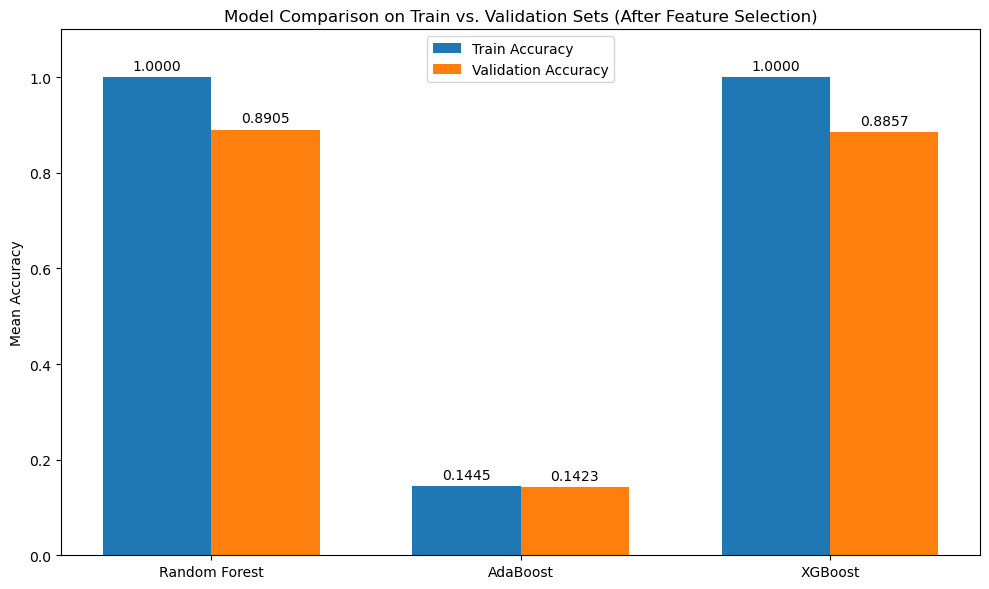


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7       0.89      0.40      0.55        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21       1.00      0.95  

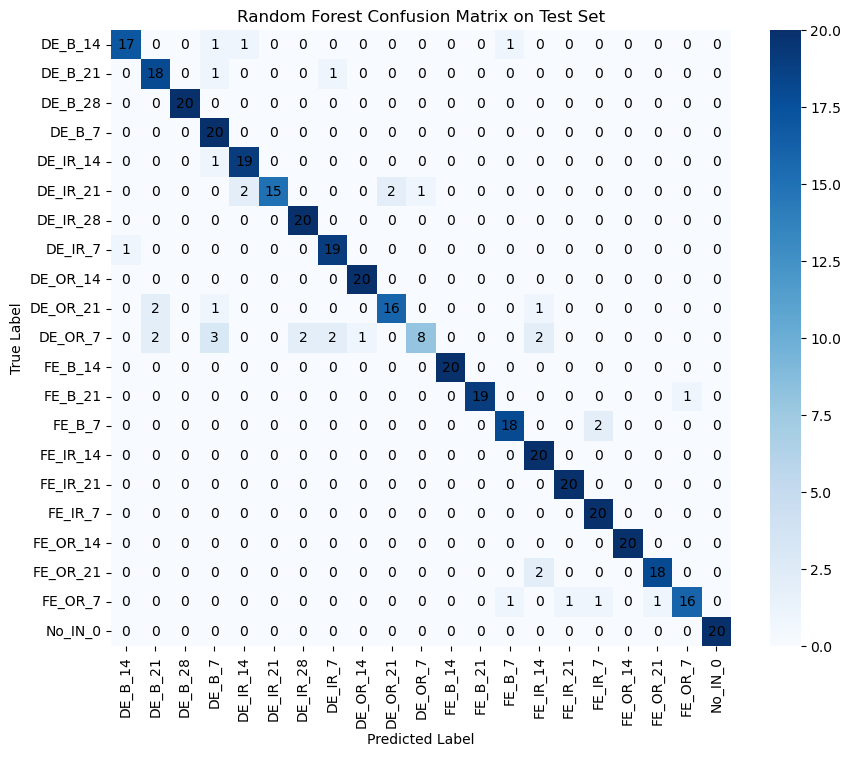


🔄 Generating feature importance chart for Random Forest...


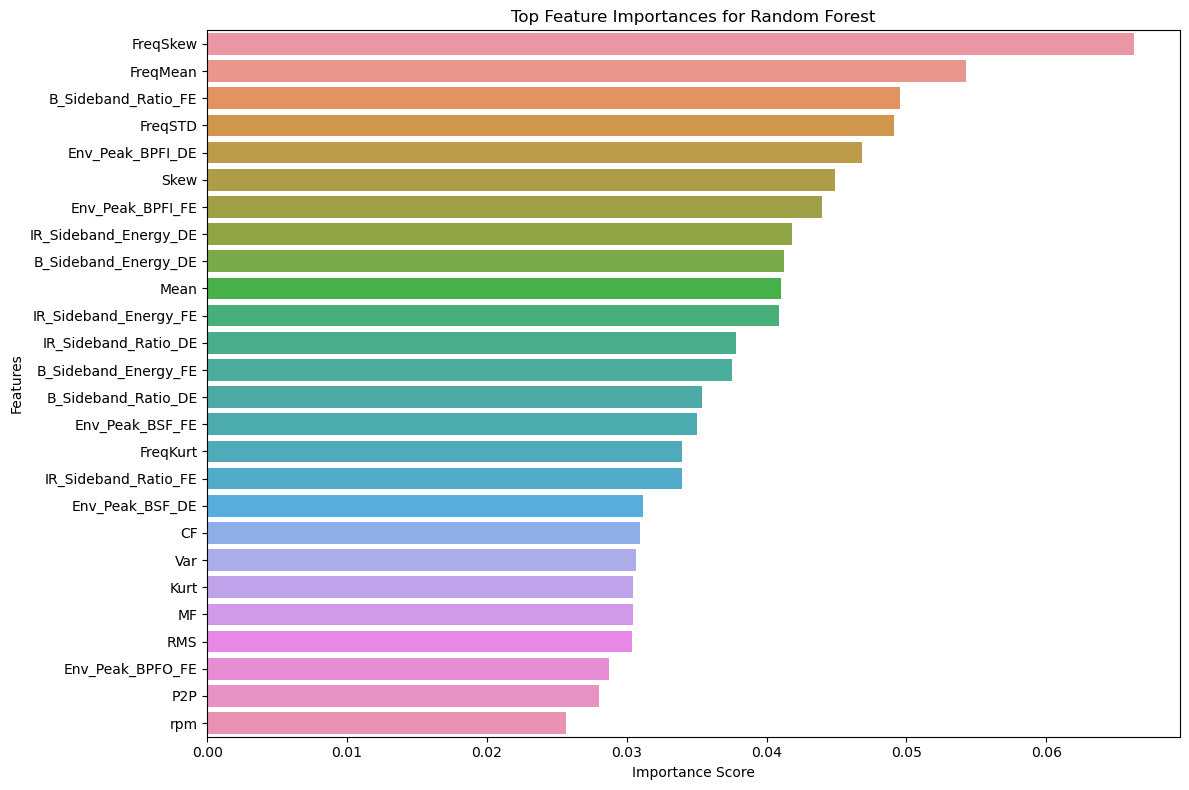


✅ Trained model has been saved to: 'random_forest_final_model.pkl'

--- Stage 4: Predicting on Target Domain Data ---
✅ Successfully loaded 'processed_data - target.pkl'.

🔄 Aligning target data with the 26 selected features...
✅ Target data aligned. Shape: (16, 26)

🔄 Predicting with the final Random Forest model...

🎉 --- Target Domain Prediction Complete --- 🎉
Final Predictions:
    Sample_Index Predicted_Label
0              0         DE_B_14
1              1        DE_OR_21
2              2         DE_B_28
3              3         FE_B_14
4              4         DE_B_28
5              5        FE_IR_14
6              6         DE_B_14
7              7         DE_B_28
8              8        DE_IR_21
9              9         DE_B_28
10            10         No_IN_0
11            11         No_IN_0
12            12         DE_B_14
13            13         DE_B_28
14            14         DE_B_14
15            15         FE_B_14

✅ Predictions have been saved to 'target_domain_pred

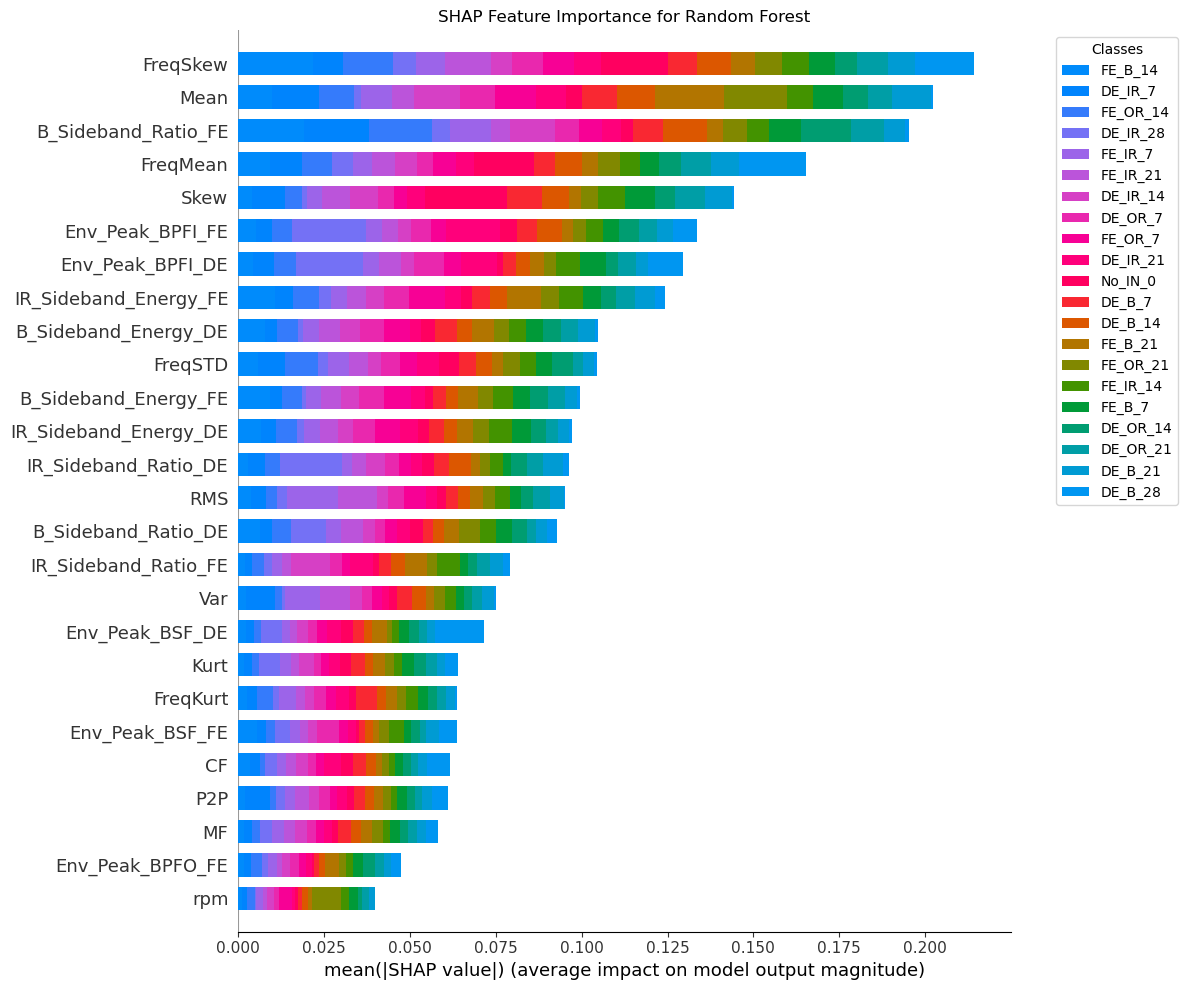

✅ SHAP bar plot saved.


In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 主要实验函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__}...")
    rfecv = RFECV(estimator=model_for_selection, step=1, cv=kfold, scoring="f1_weighted", min_features_to_select=5, n_jobs=-1)
    rfecv.fit(X_train, y_train)
    print(f"✅ RFECV complete. Optimal number of features found: {rfecv.n_features_}")
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    X_train_selected = rfecv.transform(X_train)
    return pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features), selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage 2: Model Comparison{title_suffix} ---")
    results = []
    for model_name, model in models.items():
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name, 'Train_Accuracy_Mean': cv_results['train_accuracy'].mean(), 'Validation_Accuracy_Mean': cv_results['test_accuracy'].mean()}
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:\n{results_df.round(4).to_string()}")
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text, y_pred_text = le.inverse_transform(y_test), le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")
    return model

def predict_target_domain(model, model_name, target_data_path, selected_features, le):
    print("\n" + "="*50 + f"\n--- Stage 4: Predicting on Target Domain Data ---")
    try:
        with open(target_data_path, 'rb') as f:
            target_data_bundle = pickle.load(f)
        X_target = target_data_bundle['X_target']
        print(f"✅ Successfully loaded '{target_data_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: Target data file '{target_data_path}' not found."); return
        
    print(f"\n🔄 Aligning target data with the {len(selected_features)} selected features...")
    X_target_selected = X_target[selected_features]
    print(f"✅ Target data aligned. Shape: {X_target_selected.shape}")
    print(f"\n🔄 Predicting with the final {model_name} model...")
    target_predictions_encoded = model.predict(X_target_selected)
    target_predictions_text = le.inverse_transform(target_predictions_encoded)
    predictions_df = pd.DataFrame({'Sample_Index': X_target.index, 'Predicted_Label': target_predictions_text})
    print("\n🎉 --- Target Domain Prediction Complete --- 🎉\nFinal Predictions:")
    print(predictions_df.to_string())
    output_filename = '../results/预测结果/target_domain_predictions.csv'
    predictions_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions have been saved to '{output_filename}'")


# --- 【重新加入】独立的SHAP分析函数 ---
def analyze_with_shap(model, model_name, X_train, data_to_explain, class_names):
    """
    使用SHAP为训练好的模型生成可解释性分析图。
    """
    print("\n" + "="*50)
    print(f"--- Stage 5: Post-hoc Interpretability Analysis with SHAP ---")
    print("="*50)
    print(f"\n🔄 Generating SHAP analysis for {model_name}...")

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(data_to_explain)
        
        # --- 绘制SHAP特征重要性条形图 ---
        print("\n🔄 Generating SHAP Feature Importance Bar Plot...")
        
        # 修改处：添加了max_display参数
        shap.summary_plot(shap_values, 
                          data_to_explain, 
                          plot_type="bar", 
                          class_names=class_names, 
                          show=False, 
                          max_display=50)  # 设置为希望显示的特征数量
        
        fig = plt.gcf()
        ax = plt.gca()
        
        fig.set_size_inches(12, 10)  # 增加图形尺寸以容纳更多特征
        plt.title(f'SHAP Feature Importance for {model_name}')
        
        ax.legend(title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig(f'../results/shap/{model_name.replace(" ", "_").lower()}_shap_bar_plot.png', bbox_inches='tight')
        plt.show()
        print(f"✅ SHAP bar plot saved.")
        
    except Exception as e:
        print(f"❌ SHAP analysis failed: {e}")


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # 加载数据
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # 标签编码
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    # 定义模型
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 阶段 1: 特征选择
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    X_test_selected = X_test_full[selected_feature_names]

    # 阶段 2: 在筛选后的特征上重新比选模型
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # 阶段 3: 训练、评估并保存最终模型
    final_trained_model = train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

    # 阶段 4: 对目标域数据进行预测
    predict_target_domain(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        target_data_path='../data/processed/processed_data - target.pkl',
        selected_features=selected_feature_names,
        le=le
    )
    
    # **【最终阶段】**: 对最终模型进行SHAP可解释性分析
    analyze_with_shap(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        data_to_explain=X_test_selected,
        class_names=le.classes_
    )

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier...
✅ RFECV complete. Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison (After Feature Selection) ---

Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8905
AdaBoost                    0.1445                    0.1423
XGBoost           

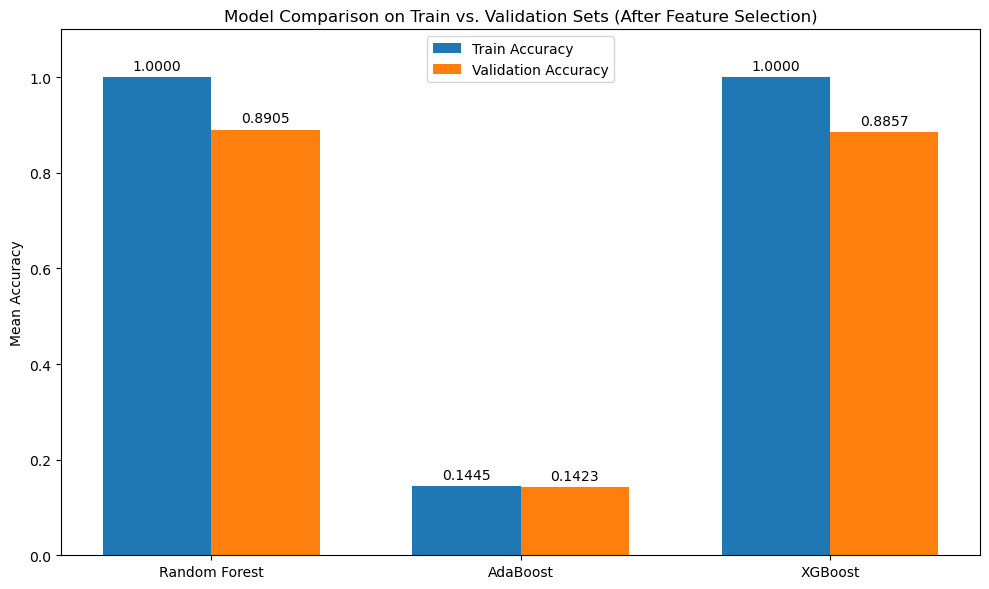


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7       0.89      0.40      0.55        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21       1.00      0.95  

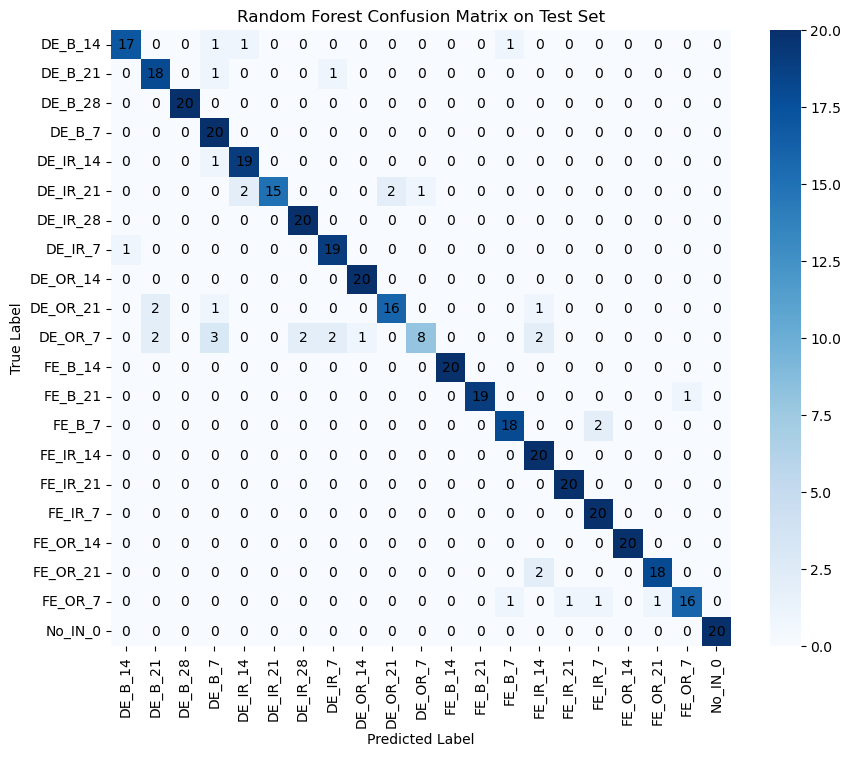


🔄 Generating feature importance chart for Random Forest...


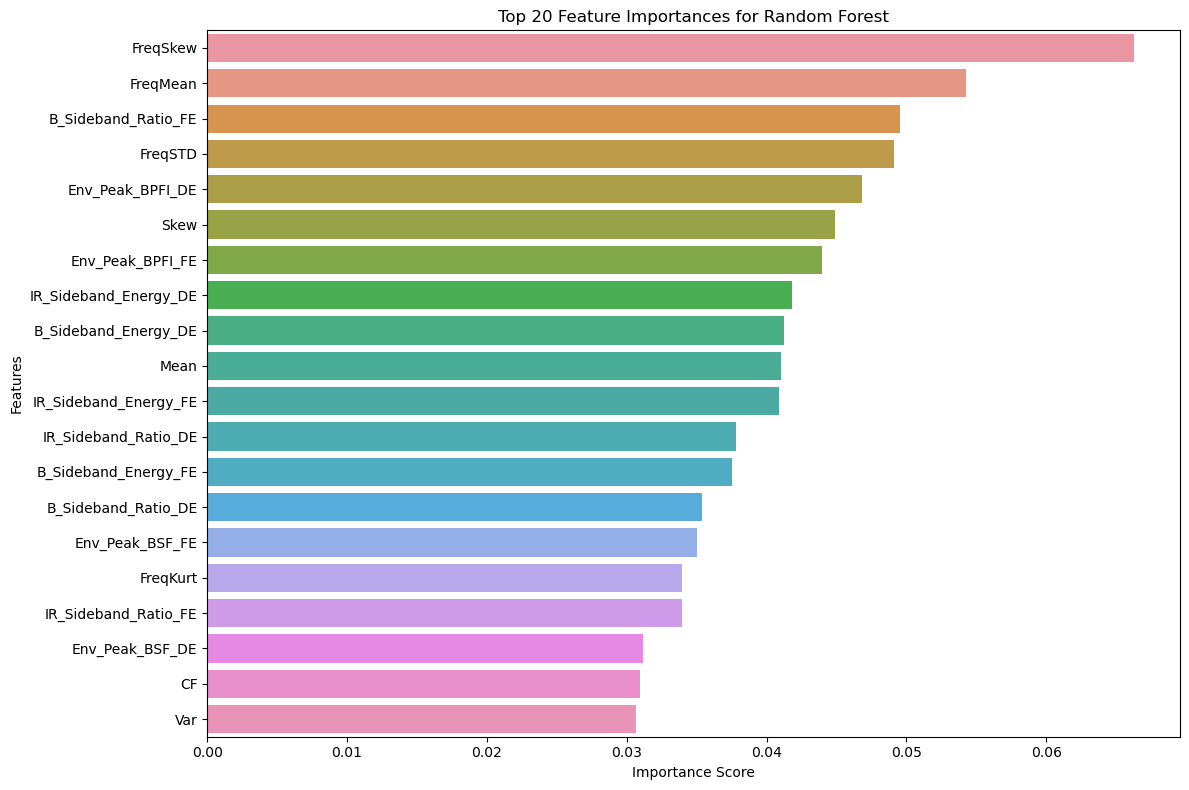


✅ Trained model has been saved to: 'random_forest_final_model.pkl'

--- Stage 4: Predicting on Target Domain Data ---
✅ Successfully loaded 'processed_data - target.pkl'.

🔄 Aligning target data with the 26 selected features...
✅ Target data aligned. Shape: (16, 26)

🔄 Predicting with the final Random Forest model...

🎉 --- Target Domain Prediction Complete --- 🎉
Final Predictions:
    Sample_Index Predicted_Label
0              0         DE_B_14
1              1        DE_OR_21
2              2         DE_B_28
3              3         FE_B_14
4              4         DE_B_28
5              5        FE_IR_14
6              6         DE_B_14
7              7         DE_B_28
8              8        DE_IR_21
9              9         DE_B_28
10            10         No_IN_0
11            11         No_IN_0
12            12         DE_B_14
13            13         DE_B_28
14            14         DE_B_14
15            15         FE_B_14

✅ Predictions have been saved to 'target_domain_pred

<Figure size 1200x1000 with 0 Axes>

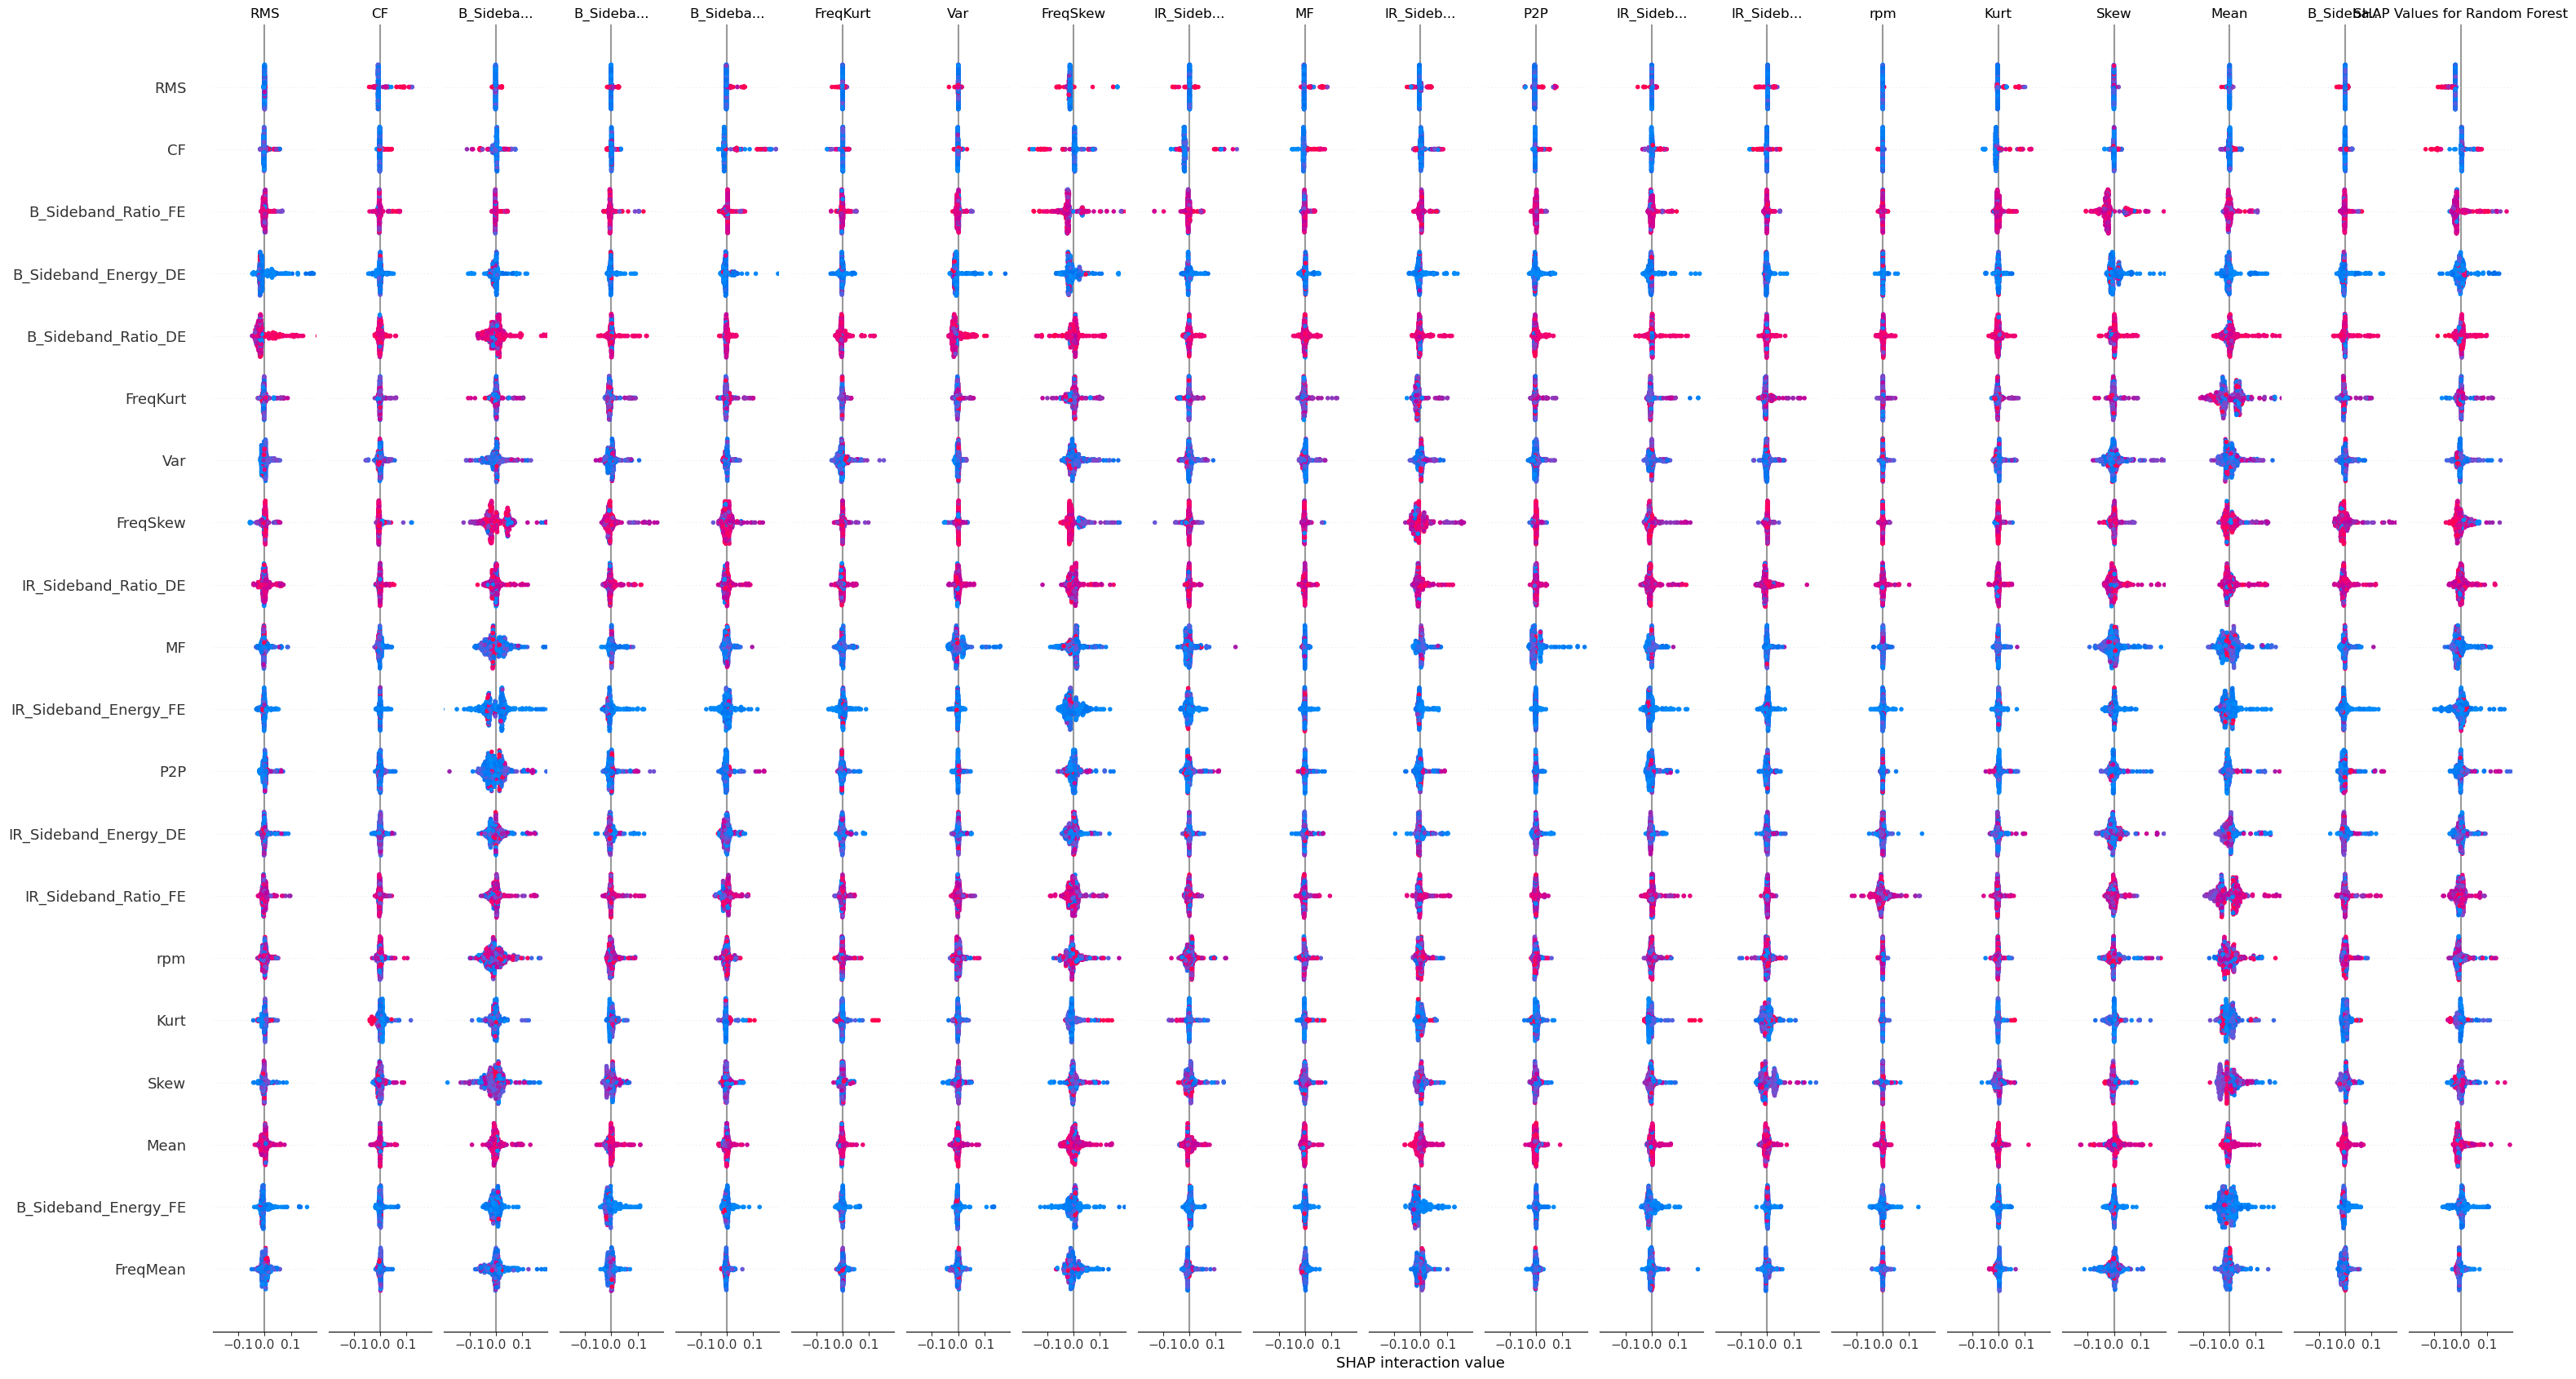

✅ SHAP beeswarm plot saved as 'random_forest_shap_beeswarm.png'


In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {len(top_features)} Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 主要实验函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__}...")
    rfecv = RFECV(estimator=model_for_selection, step=1, cv=kfold, scoring="f1_weighted", min_features_to_select=5, n_jobs=-1)
    rfecv.fit(X_train, y_train)
    print(f"✅ RFECV complete. Optimal number of features found: {rfecv.n_features_}")
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    X_train_selected = rfecv.transform(X_train)
    return pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features), selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage 2: Model Comparison{title_suffix} ---")
    results = []
    for model_name, model in models.items():
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name, 'Train_Accuracy_Mean': cv_results['train_accuracy'].mean(), 'Validation_Accuracy_Mean': cv_results['test_accuracy'].mean()}
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:\n{results_df.round(4).to_string()}")
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text, y_pred_text = le.inverse_transform(y_test), le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")
    return model

def predict_target_domain(model, model_name, target_data_path, selected_features, le):
    print("\n" + "="*50 + f"\n--- Stage 4: Predicting on Target Domain Data ---")
    try:
        with open(target_data_path, 'rb') as f:
            target_data_bundle = pickle.load(f)
        X_target = target_data_bundle['X_target']
        print(f"✅ Successfully loaded '{target_data_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: Target data file '{target_data_path}' not found."); return
        
    print(f"\n🔄 Aligning target data with the {len(selected_features)} selected features...")
    X_target_selected = X_target[selected_features]
    print(f"✅ Target data aligned. Shape: {X_target_selected.shape}")
    print(f"\n🔄 Predicting with the final {model_name} model...")
    target_predictions_encoded = model.predict(X_target_selected)
    target_predictions_text = le.inverse_transform(target_predictions_encoded)
    predictions_df = pd.DataFrame({'Sample_Index': X_target.index, 'Predicted_Label': target_predictions_text})
    print("\n🎉 --- Target Domain Prediction Complete --- 🎉\nFinal Predictions:")
    print(predictions_df.to_string())
    output_filename = '../results/预测结果/target_domain_predictions.csv'
    predictions_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions have been saved to '{output_filename}'")


# --- 修正后的SHAP分析函数 ---
def analyze_with_shap(model, model_name, X_train, data_to_explain, class_names):
    """
    使用SHAP为训练好的模型生成可解释性分析图。
    生成蜂群图(beeswarm plot)以显示特征影响的方向和大小。
    """
    print("\n" + "="*50)
    print(f"--- Stage 5: Post-hoc Interpretability Analysis with SHAP ---")
    print("="*50)
    print(f"\n🔄 Generating SHAP analysis for {model_name}...")

    try:
        # 创建解释器
        explainer = shap.TreeExplainer(model)
        
        # 计算SHAP值
        shap_values = explainer.shap_values(data_to_explain)
        
        # 获取特征名称
        feature_names = data_to_explain.columns.tolist()
        
        # 检查是多分类还是二分类问题
        if isinstance(shap_values, list):
            # 多分类问题：为每个类别生成一个蜂群图
            print(f"检测到多分类问题，共有 {len(shap_values)} 个类别")
            
            for i, class_name in enumerate(class_names):
                print(f"\n🔄 Generating SHAP beeswarm plot for class '{class_name}'...")
                
                plt.figure(figsize=(12, 10))
                
                # 绘制蜂群图
                shap.summary_plot(
                    shap_values[i], 
                    data_to_explain, 
                    feature_names=feature_names,
                    show=False,
                    max_display=min(20, len(feature_names))  # 限制显示的特征数量
                )
                
                plt.title(f'SHAP Values for {model_name} - Class: {class_name}')
                plt.tight_layout()
                
                # 保存图像
                filename = f'../results/shap/{model_name.replace(" ", "_").lower()}_shap_beeswarm_{class_name}.png'
                plt.savefig(filename, bbox_inches='tight', dpi=300)
                plt.show()
                print(f"✅ SHAP beeswarm plot for class '{class_name}' saved as '{filename}'")
        
        else:
            # 二分类问题
            print(f"\n🔄 Generating SHAP beeswarm plot...")
            
            plt.figure(figsize=(12, 10))
            
            # 绘制蜂群图
            shap.summary_plot(
                shap_values, 
                data_to_explain, 
                feature_names=feature_names,
                show=False,
                max_display=min(20, len(feature_names))  # 限制显示的特征数量
            )
            
            plt.title(f'SHAP Values for {model_name}')
            plt.tight_layout()
            
            # 保存图像
            filename = f'../results/shap/{model_name.replace(" ", "_").lower()}_shap_beeswarm.png'
            plt.savefig(filename, bbox_inches='tight', dpi=300)
            plt.show()
            print(f"✅ SHAP beeswarm plot saved as '{filename}'")
            
    except Exception as e:
        print(f"❌ SHAP analysis failed: {e}")
        import traceback
        traceback.print_exc()


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # 加载数据
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # 标签编码
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    # 定义模型
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 阶段 1: 特征选择
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    X_test_selected = X_test_full[selected_feature_names]

    # 阶段 2: 在筛选后的特征上重新比选模型
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # 阶段 3: 训练、评估并保存最终模型
    final_trained_model = train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

    # 阶段 4: 对目标域数据进行预测
    predict_target_domain(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        target_data_path='../data/processed/processed_data - target.pkl',
        selected_features=selected_feature_names,
        le=le
    )
    
    # **【最终阶段】**: 对最终模型进行SHAP可解释性分析
    analyze_with_shap(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        data_to_explain=X_test_selected,
        class_names=le.classes_
    )

# 使用L1正则化的嵌入式方法 (SelectFromModel) 的完整代码

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Feature Selection using SelectFromModel with L1 Regularization ---

🔄 Starting feature selection...
✅ Feature selection complete.
   - Selected 14 features out of 27.
   - Selected features are: ['rpm', 'Mean', 'RMS', 'Skew', 'FreqMean', 'FreqSTD', 'FreqSkew', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison via Cross-Validation (After L1 Feature Selection) ---

🔄 Starting cross-validation...
   - Evaluating: Random Forest...
   - Evaluating: AdaBoost...
   - Evaluating: XGBoost...

Model Performance Comparison (After L1 Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8815
AdaBoost                    0.1445                    0.1423
XGBoost       

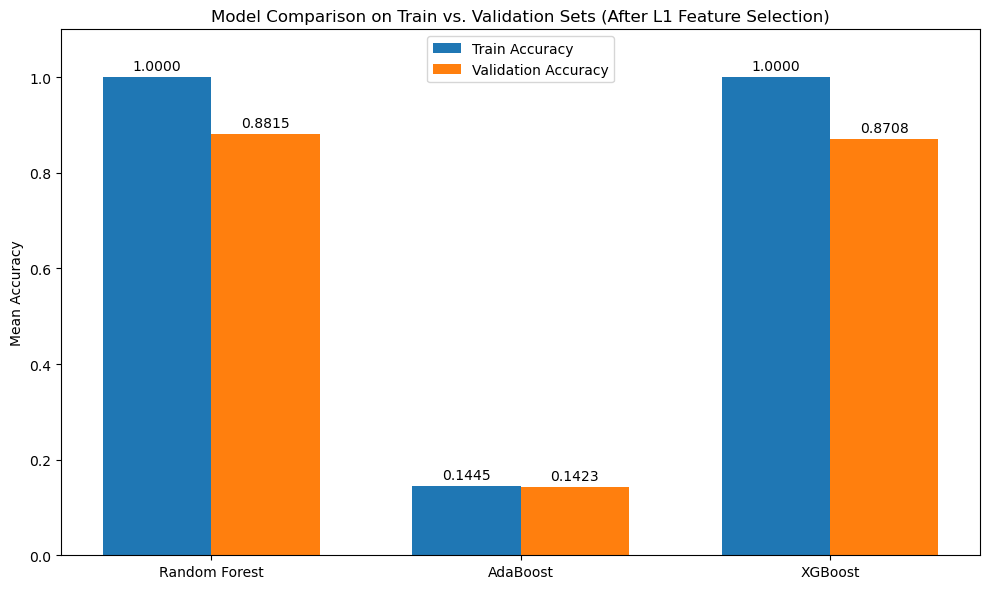


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation of the Best Model (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9024

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.90      0.90      0.90        20
     DE_B_21       0.78      0.90      0.84        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.70      0.82        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.83      0.95      0.88        20
    DE_OR_14       0.95      0.95      0.95        20
    DE_OR_21       0.94      0.75      0.83        20
     DE_OR_7       0.70      0.35      0.47        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21     

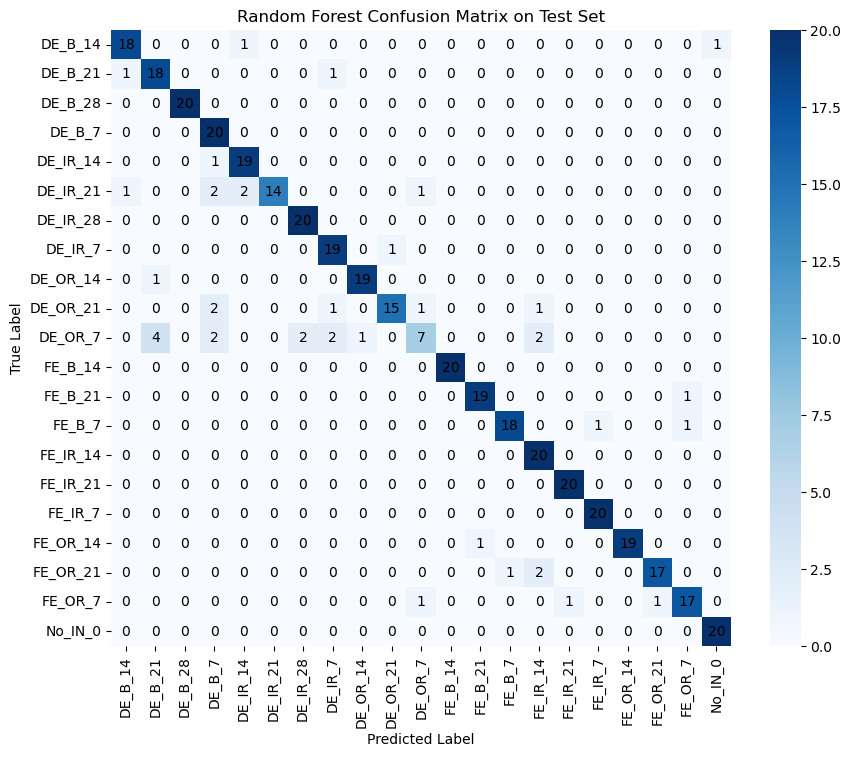


🔄 Generating feature importance chart for Random Forest...


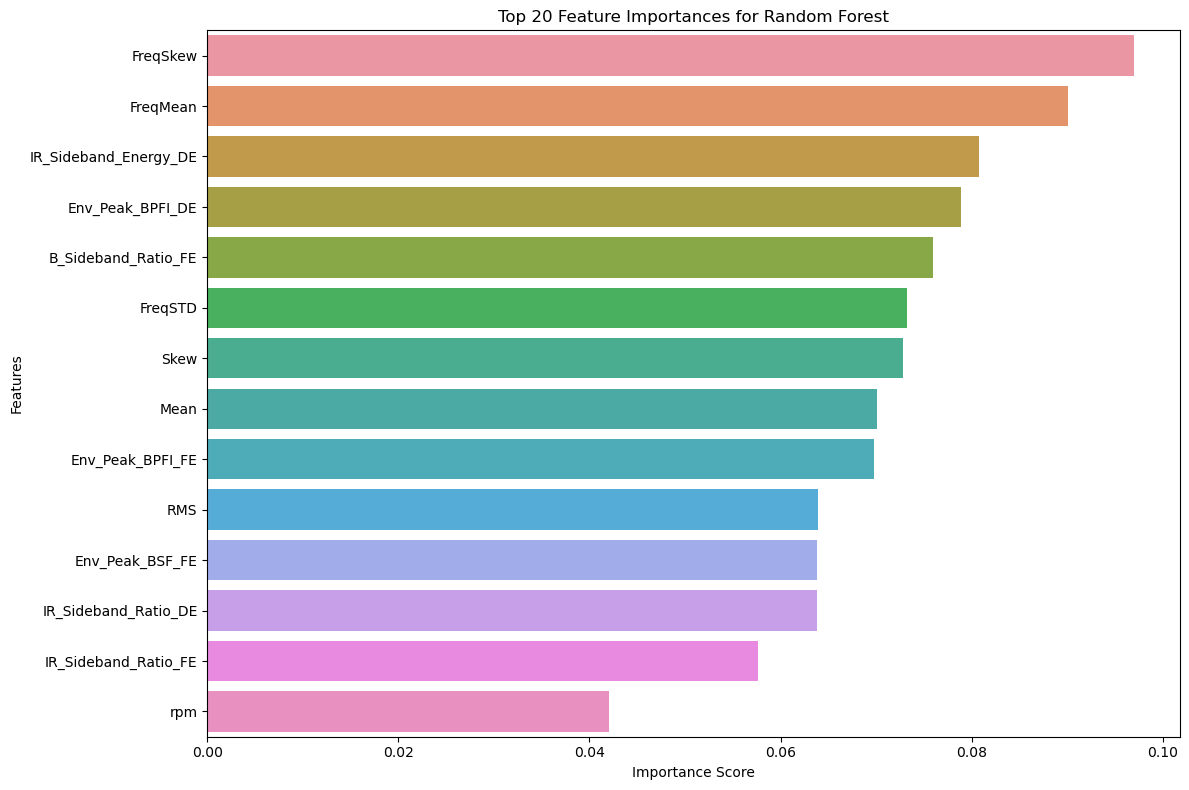


✅ Trained model has been saved to: 'random_forest_final_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 新增导入
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 (保持不变) ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 20 Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 特征选择与实验函数 ---
def select_features_with_l1(X_train, y_train):
    print("\n--- Stage 1: Feature Selection using SelectFromModel with L1 Regularization ---")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    l1_estimator = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42, max_iter=1000)
    
    print("\n🔄 Starting feature selection...")
    selector = SelectFromModel(estimator=l1_estimator, prefit=False, threshold='median')
    selector.fit(X_train_scaled, y_train)
    
    selected_mask = selector.get_support()
    selected_features = X_train.columns[selected_mask]
    
    print(f"✅ Feature selection complete.")
    print(f"   - Selected {len(selected_features)} features out of {len(X_train.columns)}.")
    print(f"   - Selected features are: {selected_features.tolist()}")
    
    return selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage {2 if title_suffix else 1}: Model Comparison via Cross-Validation{title_suffix} ---")
    # ... (函数体与之前相同, 此处省略)
    print("\n🔄 Starting cross-validation...")
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:")
    print(results_df.round(4).to_string())
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation of the Best Model ({model_name}) ---")
    # ... (函数体与之前相同, 此处省略)
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # **阶段 1: 特征选择**
    selected_feature_names = select_features_with_l1(X_train_full, y_train_encoded)
    X_train_selected = X_train_full[selected_feature_names]
    X_test_selected = X_test_full[selected_feature_names]

    # **阶段 2: 在筛选后的特征上重新比选模型**
    best_model_name = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After L1 Feature Selection)"
    )

    # **阶段 3: 训练、评估并保存最终模型**
    train_and_evaluate_final_model(
        models[best_model_name], best_model_name,
        X_train_selected, y_train_encoded,
        X_test_selected, y_test_encoded,
        le
    )

# 使用排列重要性 (PermutationImportance) 的完整代码

✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Feature Selection using Permutation Importance ---

🔄 Training a baseline RandomForestClassifier model for importance analysis...

🔄 Calculating permutation importances... (This may take a while)
✅ Permutation Importance analysis complete.
   - Top 10 most important features:
                 Feature  Importance
20   B_Sideband_Ratio_FE    0.007976
11              FreqSkew    0.001310
4                   Skew    0.001071
1                   Mean    0.000417
0                    rpm    0.000357
10               FreqSTD    0.000357
25      Env_Peak_BPFI_FE    0.000119
21      Env_Peak_BPFO_DE    0.000119
26       Env_Peak_BSF_FE    0.000119
18  IR_Sideband_Ratio_FE    0.000060

   - Selected 3 features with importance > 0.001.

--- Stage 2: Model Comparison via Cross-Validation (After Permutation Importance Selection) ---

🔄 Starting cross-validation...
   - Evaluating: Random Forest...
   - Evaluating: AdaBoost...
   - Evaluating

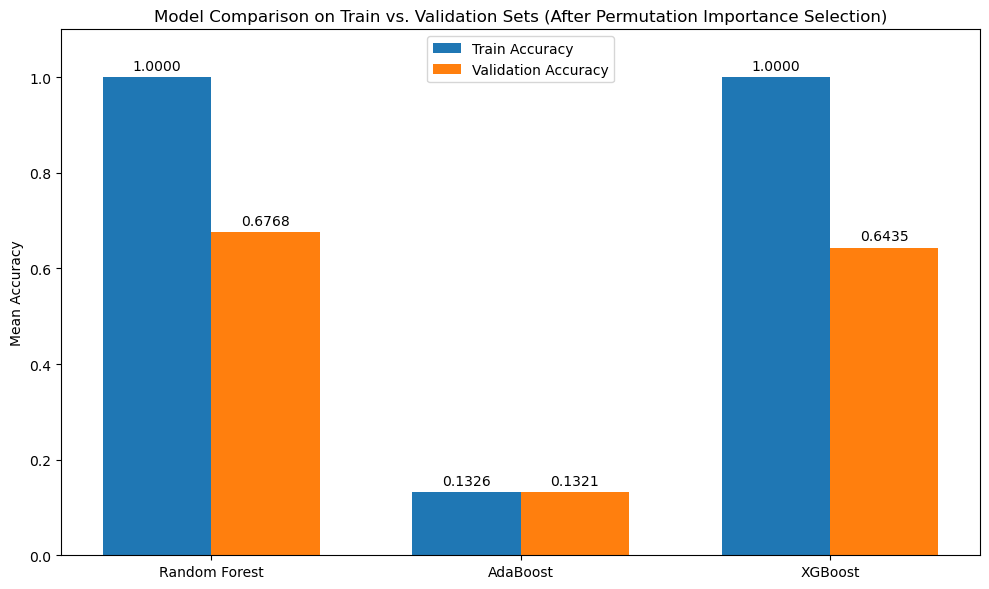


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation of the Best Model (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.7333

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.48      0.55      0.51        20
     DE_B_21       0.77      0.50      0.61        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.55      0.85      0.67        20
    DE_IR_14       0.79      0.55      0.65        20
    DE_IR_21       0.80      0.60      0.69        20
    DE_IR_28       0.90      0.90      0.90        20
     DE_IR_7       0.63      0.60      0.62        20
    DE_OR_14       0.65      0.65      0.65        20
    DE_OR_21       0.75      0.60      0.67        20
     DE_OR_7       0.56      0.25      0.34        20
     FE_B_14       0.69      0.90      0.78        20
     FE_B_21     

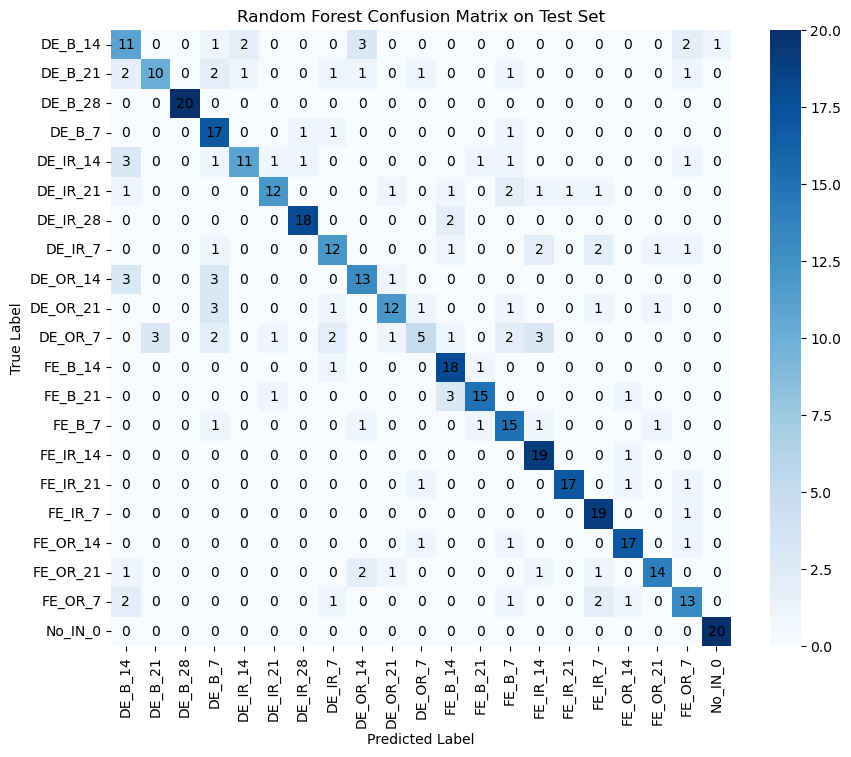


🔄 Generating feature importance chart for Random Forest...


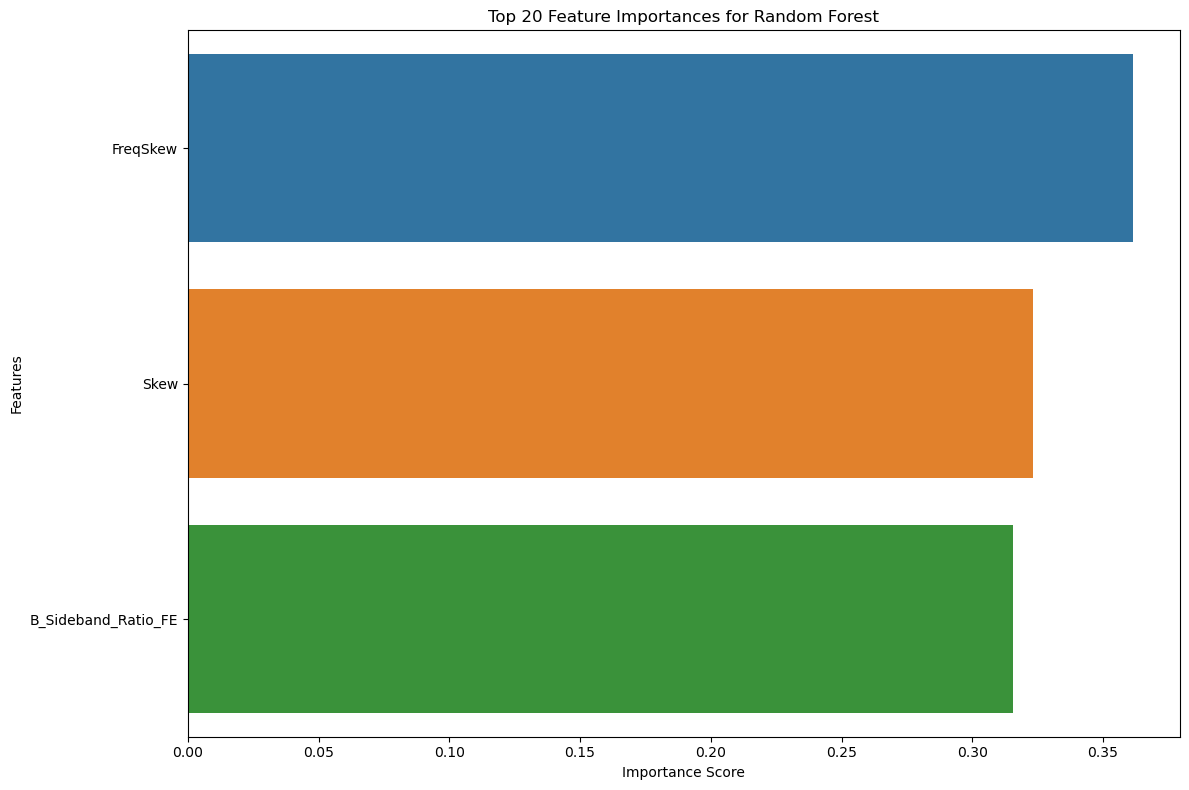


✅ Trained model has been saved to: 'random_forest_final_model.pkl'


In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 新增导入
from sklearn.inspection import permutation_importance
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 (与方案一完全相同, 此处省略) ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    # ... (代码与上一版完全相同, 此处省略以保持简洁)
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    # ... (代码与上一版完全相同, 此处省略)
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    # ... (代码与上一版完全相同, 此处省略)
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 20 Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()


# --- 特征选择与实验函数 ---
def select_features_with_permutation(X_train, y_train, model_for_selection, min_importance_threshold=0.001):
    """
    使用排列重要性进行特征分析和选择。
    """
    print("\n--- Stage 1: Feature Selection using Permutation Importance ---")
    
    print(f"\n🔄 Training a baseline {type(model_for_selection).__name__} model for importance analysis...")
    model_for_selection.fit(X_train, y_train)
    
    print("\n🔄 Calculating permutation importances... (This may take a while)")
    result = permutation_importance(
        model_for_selection, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
    )
    
    perm_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)

    # 根据阈值选择特征
    selected_features = perm_importance_df[perm_importance_df['Importance'] > min_importance_threshold]['Feature']
    
    print(f"✅ Permutation Importance analysis complete.")
    print("   - Top 10 most important features:")
    print(perm_importance_df.head(10).to_string())
    print(f"\n   - Selected {len(selected_features)} features with importance > {min_importance_threshold}.")
    
    return selected_features.tolist()

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage {2 if title_suffix else 1}: Model Comparison via Cross-Validation{title_suffix} ---")
    # ... (函数体与之前相同, 此处省略)
    print("\n🔄 Starting cross-validation...")
    results = []
    for model_name, model in models.items():
        print(f"   - Evaluating: {model_name}...")
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name}
        model_result['Train_Accuracy_Mean'] = cv_results['train_accuracy'].mean()
        model_result['Validation_Accuracy_Mean'] = cv_results['test_accuracy'].mean()
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:")
    print(results_df.round(4).to_string())
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    # ... (函数体与之前相同, 此处省略)
    print(f"\n--- Stage 3: Final Training and Evaluation of the Best Model ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text = le.inverse_transform(y_test)
    y_pred_text = le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")


# --- 主执行函数 ---
if __name__ == "__main__":
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # **阶段 1: 特征选择**
    # 我们选用一个相对快速且强大的模型（如随机森林）来帮助我们进行特征重要性判断
    model_for_fs = RandomForestClassifier(random_state=42)
    selected_feature_names = select_features_with_permutation(X_train_full, y_train_encoded, model_for_fs)
    X_train_selected = X_train_full[selected_feature_names]
    X_test_selected = X_test_full[selected_feature_names]

    # **阶段 2: 在筛选后的特征上重新比选模型**
    best_model_name = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Permutation Importance Selection)"
    )

    # **阶段 3: 训练、评估并保存最终模型**
    train_and_evaluate_final_model(
        models[best_model_name], best_model_name,
        X_train_selected, y_train_encoded,
        X_test_selected, y_test_encoded,
        le
    )